In [1]:
#..... Alll EXPERIMENT WITH NUMERICAL VALUE AND REAL_LIFE APPLICATION

In [ ]:
#------------------------------                            SIMULATION EXPERIMENTS                                               ------------------------------

In [ ]:
#=============================================================================================================================================================
#............................                               UPDATED VERSION ..................................................................................
#=============================================================================================================================================================

In [10]:
import numpy as np
import openpyxl
import pandas as pd
from scipy import stats
from scipy.special import erf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
import shap
import warnings
warnings.filterwarnings('ignore')
import os
import time
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages

np.random.seed(42)

# Create output directories
output_dir = "site_Theoretical_UPDATE"
plots_dir = os.path.join(output_dir, "plots")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Timestamp for file names
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================================
# 1. THEORETICAL FOUNDATIONS
# ============================================================================

class SiTeTheoretical:
    """
    Theoretical derivations and proofs for SiTe framework.
    """
    
    @staticmethod
    def compute_rank_statistic(shap_values):
        """
        Compute rank statistic R_j for each feature.
        """
        if len(shap_values.shape) == 1:
            shap_values = shap_values.reshape(-1, 1)
        
        n, d = shap_values.shape
        abs_shap = np.abs(shap_values)
        ranks = np.argsort(np.argsort(abs_shap, axis=1), axis=1) + 1
        R = np.sum(ranks, axis=0)
        
        return R
    
    @staticmethod
    def asymptotic_null_distribution(d, n):
        """Theoretical null distribution of rank statistic R_j under H0."""
        mean_per_instance = (d + 1) / 2
        var_per_instance = (d**2 - 1) / 12
        mean_total = n * mean_per_instance
        var_total = n * var_per_instance
        
        return mean_total, var_total
    
    @staticmethod
    def compute_z_score(R_j, d, n):
        """Compute standardized Z-score for rank statistic."""
        mean_h0, var_h0 = SiTeTheoretical.asymptotic_null_distribution(d, n)
        z = (R_j - mean_h0) / np.sqrt(var_h0)
        return z
    
    @staticmethod
    def p_value_from_z(z, one_sided=True):
        """Compute p-value from Z-score."""
        if one_sided:
            p = 0.5 * (1 - erf(z / np.sqrt(2)))
        else:
            p = 1 - (erf(np.abs(z) / np.sqrt(2)))
        return p
    
    @staticmethod
    def correlation_adjustment(shap_values):
        """Adjust variance for feature correlations."""
        if len(shap_values.shape) == 1:
            shap_values = shap_values.reshape(-1, 1)
        
        n, d = shap_values.shape
        abs_shap = np.abs(shap_values)
        ranks = np.argsort(np.argsort(abs_shap, axis=1), axis=1) + 1
        cov_matrix = np.cov(ranks, rowvar=False)
        diag_var = n * (d**2 - 1) / 12
        cov_sum = np.sum(cov_matrix, axis=1) - np.diag(cov_matrix)
        adjusted_var = diag_var + cov_sum * (n - 1)
        
        return adjusted_var
    
    @staticmethod
    def benjamini_hochberg(p_values, q=0.05):
        """Benjamini-Hochberg procedure for FAIR control."""
        m = len(p_values)
        sorted_indices = np.argsort(p_values)
        sorted_p = p_values[sorted_indices]
        ranks = np.arange(1, m + 1)
        critical_values = (ranks / m) * q
        
        rejected_sorted = sorted_p <= critical_values
        if not np.any(rejected_sorted):
            k_max = 0
        else:
            k_max = np.max(ranks[rejected_sorted])
        
        rejected = np.zeros(m, dtype=bool)
        if k_max > 0:
            rejected[sorted_indices[:k_max]] = True
        
        adjusted_p = np.zeros(m)
        for i, idx in enumerate(sorted_indices):
            adjusted_p[idx] = np.min([np.min(sorted_p[i:] * m / (np.arange(i, m) + 1)), 1])
        
        return rejected, adjusted_p
    
    @staticmethod
    def significance_aware_score(shap_importance, p_adj, epsilon=1e-10):
        """Compute significance-aware score: S_j = -log10(p_j^adj + ε) * Ψ_j"""
        return -np.log10(p_adj + epsilon) * shap_importance

# ============================================================================
# 2. DATA GENERATION
# ============================================================================

class DataGenerator:
    """Generate synthetic datasets with known ground truth."""
    
    @staticmethod
    def synthetic_linear(n_samples=1000, n_informative=10, n_noise=40):
        """Generate linear synthetic data: y = Σ w_j x_j + ε"""
        n_features = n_informative + n_noise
        X = np.random.randn(n_samples, n_features)
        w = np.random.randn(n_informative)
        w = w / np.linalg.norm(w)
        y_linear = X[:, :n_informative] @ w
        noise = np.random.randn(n_samples) * 0.1
        y = y_linear + noise
        true_indices = list(range(n_informative))
        
        return X, y, true_indices
    
    @staticmethod
    def synthetic_nonlinear(n_samples=1000, n_informative=5, n_noise=15):
        """Generate nonlinear synthetic data: y = I(Σ x_j² > χ²_{df,0.5})"""
        n_features = n_informative + n_noise
        X = np.random.randn(n_samples, n_features)
        informative_squares = np.sum(X[:, :n_informative]**2, axis=1)
        threshold = stats.chi2.ppf(0.5, df=n_informative)
        y = (informative_squares > threshold).astype(int)
        true_indices = list(range(n_informative))
        
        return X, y, true_indices

# ============================================================================
# 3. SITE FRAMEWORK IMPLEMENTATION
# ============================================================================

class SiTe:
    """Main SiTe framework implementation."""
    
    def __init__(self, q=0.05, use_correlation_adjustment=True):
        self.q = q
        self.use_correlation_adjustment = use_correlation_adjustment
        self.results_ = {}
        
    def fit(self, shap_values, feature_names=None):
        if len(shap_values.shape) == 1:
            shap_values = shap_values.reshape(-1, 1)
        
        n, d = shap_values.shape
        
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(d)]
        
        # 1. Traditional SHAP importance
        shap_importance = np.mean(np.abs(shap_values), axis=0)
        
        # 2. Rank statistics
        R = SiTeTheoretical.compute_rank_statistic(shap_values)
        
        # 3. Z-scores and p-values
        if self.use_correlation_adjustment:
            adjusted_var = SiTeTheoretical.correlation_adjustment(shap_values)
            mean_h0, var_h0_base = SiTeTheoretical.asymptotic_null_distribution(d, n)
            z_scores = (R - mean_h0) / np.sqrt(adjusted_var)
        else:
            z_scores = SiTeTheoretical.compute_z_score(R, d, n)
        
        p_values = SiTeTheoretical.p_value_from_z(z_scores, one_sided=True)
        
        # 4. FAIR control - Core of SiTe
        rejected, p_adj = SiTeTheoretical.benjamini_hochberg(p_values, q=self.q)
        
        # 5. Calculate actual FAIR (if ground truth available)
        actual_fair = None
        if hasattr(self, 'true_indices'):
            fp = sum([1 for i in range(d) if rejected[i] and i not in self.true_indices])
            tp_fp = sum(rejected)
            actual_fair = fp / tp_fp if tp_fp > 0 else 0
        
        # 6. Significance-aware scores
        sig_scores = SiTeTheoretical.significance_aware_score(shap_importance, p_adj)
        
        # 7. Ranking
        rank_order = np.argsort(-sig_scores)
        ranks = np.zeros(d, dtype=int)
        ranks[rank_order] = np.arange(1, d + 1)
        
        # Store results
        self.results_ = {
            'feature_names': feature_names,
            'shap_importance': shap_importance,
            'rank_statistics': R,
            'z_scores': z_scores,
            'p_values': p_values,
            'rejected': rejected,
            'p_values_adj': p_adj,
            'significance_scores': sig_scores,
            'ranks': ranks,
            'significant_features': [feature_names[i] for i in np.where(rejected)[0]],
            'target_fair': self.q,
            'actual_fair': actual_fair
        }
        
        return self
    
    def set_true_indices(self, true_indices):
        """Set ground truth for FAIR calculation."""
        self.true_indices = true_indices
        return self
    
    def get_fair_info(self):
        """Get FAIR information."""
        if not self.results_:
            return {}
            
        # Calculate false positives and true positives if ground truth available
        fp = tp = 0
        if hasattr(self, 'true_indices') and self.true_indices is not None:
            rejected = self.results_.get('rejected', [])
            for i, is_rejected in enumerate(rejected):
                if is_rejected:
                    if i in self.true_indices:
                        tp += 1
                    else:
                        fp += 1
        
        return {
            'target_fair': self.results_.get('target_fair', self.q),
            'actual_fair': self.results_.get('actual_fair'),
            'n_significant': sum(self.results_.get('rejected', [])),
            'n_total': len(self.results_.get('rejected', [])),
            'false_positives': fp,
            'true_positives': tp
        }
    
    def get_results_df(self):
        """Get results as DataFrame."""
        if not self.results_:
            return pd.DataFrame()
        
        return pd.DataFrame({
            'Feature': self.results_['feature_names'],
            'SHAP_Importance': self.results_['shap_importance'],
            'Rank_Statistic': self.results_['rank_statistics'],
            'Z_Score': self.results_['z_scores'],
            'P_Value': self.results_['p_values'],
            'P_Value_Adj': self.results_['p_values_adj'],
            'Significant': self.results_['rejected'],
            'Significance_Score': self.results_['significance_scores'],
            'Rank': self.results_['ranks']
        }).sort_values('Rank')

# ============================================================================
# 4. FAIR ANALYSIS MODULE
# ============================================================================

class FAIRAnalyzer:
    """Comprehensive FAIR analysis for SiTe vs SHAP."""
    
    def __init__(self):
        self.fair_results = {}
        self.comparison_results = {}
        
    def compute_shap_fair(self, shap_importance, true_indices, top_k=None):
        """
        Compute FAIR for standard SHAP (no multiple testing correction).
        
        Args:
            shap_importance: Mean absolute SHAP values
            true_indices: Indices of truly important features
            top_k: Number of top features to consider (default: len(true_indices))
        """
        n_features = len(shap_importance)
        n_true = len(true_indices)
        
        if top_k is None:
            top_k = n_true
        
        # Standard SHAP ranking (no FAIR control)
        shap_rank = np.argsort(-shap_importance)[:top_k]
        
        # Calculate FAIR
        false_positives = len([i for i in shap_rank if i not in true_indices])
        true_positives = len([i for i in shap_rank if i in true_indices])
        
        if len(shap_rank) > 0:
            fair = false_positives / len(shap_rank)
        else:
            fair = 0
        
        return {
            'fair': fair,
            'false_positives': false_positives,
            'true_positives': true_positives,
            'total_selected': len(shap_rank),
            'method': 'Standard_SHAP'
        }
    
    def run_fair_comparison(self, n_simulations=200, n_features=50, n_informative=10):
        """
        Run comprehensive FAIR comparison between SHAP and SiTe.
        
        Returns:
            DataFrame with FAIR comparison results
        """
        print(f"Running FAIR comparison: {n_simulations} simulations...")
        
        all_results = []
        
        for sim in range(n_simulations):
            if (sim + 1) % 20 == 0:
                print(f"  Completed {sim + 1}/{n_simulations} simulations")
            
            # Generate data with known ground truth
            X = np.random.randn(200, n_features)
            w = np.zeros(n_features)
            w[:n_informative] = np.random.randn(n_informative)
            w = w / np.linalg.norm(w)
            y = X @ w + np.random.randn(200) * 0.1
            
            # Create realistic SHAP values
            shap_values = np.random.randn(200, n_features) * 0.3
            shap_values[:, :n_informative] += X[:, :n_informative] * w[:n_informative].reshape(1, -1)
            
            true_indices = list(range(n_informative))
            
            # 1. Standard SHAP FAIR
            shap_importance = np.mean(np.abs(shap_values), axis=0)
            shap_fair_result = self.compute_shap_fair(shap_importance, true_indices)
            
            # 2. SiTe FAIR
            site = SiTe(q=0.05)
            site.set_true_indices(true_indices)
            site.fit(shap_values)
            site_fair_info = site.get_fair_info()
            
            # Calculate percent FAIR improvement using your formula
            # Improvement = (SiTe FAIR - SHAP FAIR) / SHAP FAIR * 100
            shap_fair_val = shap_fair_result['fair']
            site_fair_val = site_fair_info.get('actual_fair', 0)
            
            if shap_fair_val != 0:
                fair_improvement_pct = (site_fair_val - shap_fair_val) / shap_fair_val * 100
            else:
                fair_improvement_pct = 0
            
            # Store results
            all_results.append({
                'simulation': sim + 1,
                'shap_fair': shap_fair_val,
                'shap_fp': shap_fair_result['false_positives'],
                'shap_tp': shap_fair_result['true_positives'],
                'site_fair': site_fair_val,
                'site_fp': site_fair_info.get('false_positives', 0),
                'site_tp': site_fair_info.get('true_positives', 0),
                'site_n_sig': site_fair_info.get('n_significant', 0),
                'target_fair': 0.05,
                'fair_improvement_pct': fair_improvement_pct
            })
        
        # Convert to DataFrame
        results_df = pd.DataFrame(all_results)
        
        # Calculate summary statistics
        summary = {
            'shap_mean_fair': results_df['shap_fair'].mean(),
            'shap_std_fair': results_df['shap_fair'].std(),
            'shap_median_fair': results_df['shap_fair'].median(),
            'site_mean_fair': results_df['site_fair'].mean(),
            'site_std_fair': results_df['site_fair'].std(),
            'site_median_fair': results_df['site_fair'].median(),
            'mean_fair_improvement_pct': results_df['fair_improvement_pct'].mean(),
            'n_simulations': n_simulations
        }
        
        self.comparison_results = {
            'detailed': results_df,
            'summary': summary
        }
        
        print("\nFAIR Comparison Summary:")
        print("-" * 50)
        print(f"Standard SHAP FAIR: {summary['shap_mean_fair']:.3f} +- {summary['shap_std_fair']:.3f}")
        print(f"SiTe FAIR: {summary['site_mean_fair']:.3f} +- {summary['site_std_fair']:.3f}")
        print(f"Target FAIR: 0.050")
        print(f"Mean FAIR Improvement: {summary['mean_fair_improvement_pct']:.1f}%")
        print(f"Formula: (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100")
        
        return results_df, summary
    
    def create_fair_comparison_plot(self):
        """Create comprehensive FAIR comparison visualization."""
        if not self.comparison_results:
            print("No FAIR comparison results available. Run run_fair_comparison() first.")
            return None
        
        results_df = self.comparison_results['detailed']
        summary = self.comparison_results['summary']
        
        # Create figure with multiple subplots
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle('FAIR Comparison: Standard SHAP vs SiTe', fontsize=18, fontweight='bold')
        
        # Plot 1: FAIR distributions comparison
        ax = axes[0, 0]
        bins = np.linspace(0, 0.3, 31)
        ax.hist(results_df['shap_fair'], bins=bins, alpha=0.6, label='Standard SHAP', 
                color='red', edgecolor='black', density=True)
        ax.hist(results_df['site_fair'], bins=bins, alpha=0.6, label='SiTe', 
                color='blue', edgecolor='black', density=True)
        ax.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='Target FAIR (0.05)')
        ax.set_xlabel('FAIR')
        ax.set_ylabel('Density')
        ax.set_title('FAIR Distributions')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add text with mean values
        text_str = f"SHAP mean FAIR: {summary['shap_mean_fair']:.3f}\nSiTe mean FAIR: {summary['site_mean_fair']:.3f}"
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=14,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 2: Scatter plot of FAIR values
        ax = axes[0, 1]
        ax.scatter(results_df['shap_fair'], results_df['site_fair'], alpha=0.6, s=30)
        ax.plot([0, 0.3], [0, 0.3], 'r--', alpha=0.5, label='y=x (equal FAIR)')
        ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.7, label='Target FAIR')
        ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.7)
        ax.set_xlabel('Standard SHAP FAIR')
        ax.set_ylabel('SiTe FAIR')
        ax.set_title('FAIR Comparison: SHAP vs SiTe')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        # Plot 3: Cumulative FAIR distributions (YOUR ORIGINAL PLOT)
        ax = axes[0, 2]
        sorted_shap = np.sort(results_df['shap_fair'])
        sorted_site = np.sort(results_df['site_fair'])
        cum_shap = np.arange(1, len(sorted_shap) + 1) / len(sorted_shap)
        cum_site = np.arange(1, len(sorted_site) + 1) / len(sorted_site)
        
        ax.plot(sorted_shap, cum_shap, 'r-', linewidth=2, label='Standard SHAP')
        ax.plot(sorted_site, cum_site, 'b-', linewidth=2, label='SiTe')
        ax.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='Target FAIR')
        ax.set_xlabel('FAIR')
        ax.set_ylabel('Cumulative Probability')
        ax.set_title('Cumulative FAIR Distributions')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 4: FAIR over simulations
        ax = axes[1, 0]
        ax.plot(results_df['simulation'], results_df['shap_fair'], 'r-', alpha=0.6, label='SHAP', linewidth=1)
        ax.plot(results_df['simulation'], results_df['site_fair'], 'b-', alpha=0.6, label='SiTe', linewidth=1)
        ax.axhline(y=0.05, color='green', linestyle='--', label='Target FAIR')
        ax.axhline(y=summary['shap_mean_fair'], color='red', linestyle=':', label=f'SHAP mean: {summary["shap_mean_fair"]:.3f}')
        ax.axhline(y=summary['site_mean_fair'], color='blue', linestyle=':', label=f'SiTe mean: {summary["site_mean_fair"]:.3f}')
        ax.set_xlabel('Simulation Number')
        ax.set_ylabel('FAIR')
        ax.set_title('FAIR Across Simulations')
        ax.legend(loc='upper right', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Plot 5: False Positives comparison
        ax = axes[1, 1]
        width = 0.35
        x = np.arange(2)
        fp_means = [results_df['shap_fp'].mean(), results_df['site_fp'].mean()]
        fp_stds = [results_df['shap_fp'].std(), results_df['site_fp'].std()]
        
        bars = ax.bar(x, fp_means, width, yerr=fp_stds, capsize=5, 
                     color=['red', 'blue'], alpha=0.7)
        ax.set_xlabel('Method')
        ax.set_ylabel('Average False Positives')
        ax.set_title('False Positives Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(['Standard\nSHAP', 'SiTe'])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, fp_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{val:.1f}', ha='center', va='bottom')
        
        # Plot 6: Summary statistics with your improvement formula
        ax = axes[1, 2]
        ax.axis('off')
        
        # Create summary table
        summary_data = [
            ['Metric', 'Standard SHAP', 'SiTe', 'Improvement'],
            ['Mean FAIR', f"{summary['shap_mean_fair']:.3f}", 
             f"{summary['site_mean_fair']:.3f}", 
             f"{summary['mean_fair_improvement_pct']:+.1f}%"],
            ['Std FAIR', f"{summary['shap_std_fair']:.3f}", 
             f"{summary['site_std_fair']:.3f}", ''],
            ['Median FAIR', f"{summary['shap_median_fair']:.3f}", 
             f"{summary['site_median_fair']:.3f}", ''],
            ['Mean FP', f"{results_df['shap_fp'].mean():.1f}", 
             f"{results_df['site_fp'].mean():.1f}", 
             f"{(results_df['shap_fp'].mean() - results_df['site_fp'].mean()):.1f} fewer"],
            ['Target FAIR', 'N/A', '0.050', ''],
            ['FAIR Control', 'NO', 'YES (BH procedure)', '']
        ]
        
        table = ax.table(cellText=summary_data, cellLoc='center', 
                        loc='center', colWidths=[0.25, 0.25, 0.25, 0.25])
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)
        
        # Color cells
        for i in range(len(summary_data)):
            for j in range(len(summary_data[0])):
                cell = table[(i, j)]
                if i == 0:  # Header row
                    cell.set_facecolor('#40466e')
                    cell.set_text_props(color='white', fontweight='bold')
                elif j == 1:  # SHAP column
                    cell.set_facecolor('#ffcccc')
                elif j == 2:  # SiTe column
                    cell.set_facecolor('#cce5ff')
                elif j == 3:  # Improvement column
                    cell.set_facecolor('#d4edda')
        
        ax.set_title('Summary Statistics', fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        return fig
    
    def save_fair_results(self, timestamp):
        """Save FAIR comparison results to Excel files."""
        if not self.comparison_results:
            print("No FAIR results to save.")
            return
        
        # Save detailed results
        detailed_file = os.path.join(output_dir, f"fair_comparison_detailed_{timestamp}.xlsx")
        with pd.ExcelWriter(detailed_file, engine='openpyxl') as writer:
            self.comparison_results['detailed'].to_excel(writer, sheet_name='Detailed_Results', index=False)
            
            # Save summary
            summary_df = pd.DataFrame([self.comparison_results['summary']])
            summary_df.to_excel(writer, sheet_name='Summary', index=False)
            
            # Save statistical tests
            t_stat, p_value = stats.ttest_rel(
                self.comparison_results['detailed']['shap_fair'],
                self.comparison_results['detailed']['site_fair']
            )
            
            tests_df = pd.DataFrame({
                'Test': ['Paired t-test (SHAP vs SiTe)'],
                't-statistic': [t_stat],
                'p-value': [p_value],
                'Interpretation': ['SiTe significantly reduces FAIR' if p_value < 0.001 else 'No significant difference']
            })
            tests_df.to_excel(writer, sheet_name='Statistical_Tests', index=False)
            
            # Save FAIR by quantile
            quantiles = np.arange(0, 1.1, 0.1)
            shap_quantiles = np.quantile(self.comparison_results['detailed']['shap_fair'], quantiles)
            site_quantiles = np.quantile(self.comparison_results['detailed']['site_fair'], quantiles)
            
            quantile_df = pd.DataFrame({
                'Quantile': quantiles,
                'SHAP_FAIR': shap_quantiles,
                'SiTe_FAIR': site_quantiles,
                'Difference': shap_quantiles - site_quantiles
            })
            quantile_df.to_excel(writer, sheet_name='FAIR_Quantiles', index=False)
        
        print(f"\nFAIR comparison results saved to: {detailed_file}")
        return detailed_file

# ============================================================================
# 5. OUTPUT MANAGER
# ============================================================================

class OutputManager:
    """Manages saving all outputs to files."""
    
    @staticmethod
    def save_dataframe_to_excel(df, sheet_name, filename):
        """Save DataFrame to Excel file."""
        filepath = os.path.join(output_dir, filename)
        
        if os.path.exists(filepath):
            with pd.ExcelWriter(filepath, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
                df.to_excel(writer, sheet_name=sheet_name, index=False)
        else:
            with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
                df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        return filepath
    
    @staticmethod
    def save_figures_to_pdf(figures_dict, filename):
        """Save multiple figures to a single PDF file."""
        filepath = os.path.join(plots_dir, filename)
        
        with PdfPages(filepath) as pdf:
            for fig_name, fig in figures_dict.items():
                if fig is not None:
                    pdf.savefig(fig, bbox_inches='tight')
                    plt.close(fig)
        
        print(f"Plots saved to PDF: {filepath}")
        return filepath
    
    @staticmethod
    def save_single_figure(fig, fig_name, save_pdf=True, save_png=True):
        """Save a single figure to file."""
        if save_pdf:
            pdf_path = os.path.join(plots_dir, f"{fig_name}_{timestamp}.pdf")
            fig.savefig(pdf_path, bbox_inches='tight', format='pdf')
        
        if save_png:
            png_path = os.path.join(plots_dir, f"{fig_name}_{timestamp}.png")
            fig.savefig(png_path, bbox_inches='tight', format='png', dpi=300)
        
        plt.close(fig)

# ============================================================================
# 6. COMPREHENSIVE EXPERIMENT RUNNER
# ============================================================================

class ComprehensiveExperiment:
    """Run comprehensive experiments with FAIR analysis."""
    
    def __init__(self):
        self.all_results = {}
        self.all_figures = {}
        
    def run_demonstration(self):
        """Run a demonstration of SiTe with FAIR analysis."""
        print("\n" + "="*60)
        print("DEMONSTRATION: SiTe with FAIR Control")
        print("="*60)
        
        np.random.seed(42)
        n_samples = 200
        n_features = 30
        n_informative = 8
        
        # Create synthetic data
        X, y, true_indices = DataGenerator.synthetic_linear(
            n_samples=n_samples, 
            n_informative=n_informative, 
            n_noise=n_features - n_informative
        )
        
        # Create SHAP values
        shap_values = np.random.randn(n_samples, n_features) * 0.5
        shap_values[:, :n_informative] += np.random.randn(n_samples, n_informative) * 1.5
        
        # 1. Standard SHAP analysis (no FAIR control)
        shap_importance = np.mean(np.abs(shap_values), axis=0)
        shap_fair_analyzer = FAIRAnalyzer()
        shap_fair = shap_fair_analyzer.compute_shap_fair(shap_importance, true_indices)
        
        print("\n1. Standard SHAP Analysis (NO FAIR Control):")
        print("-" * 50)
        print(f"   Top {n_informative} features selected")
        print(f"   False Feature Identification Rate: {shap_fair['fair']:.3f} ({shap_fair['fair']*100:.1f}%)")
        print(f"   False Positives: {shap_fair['false_positives']}")
        print(f"   True Positives: {shap_fair['true_positives']}")
        
        # 2. SiTe analysis (with FAIR control)
        site = SiTe(q=0.05)
        site.set_true_indices(true_indices)
        site.fit(shap_values)
        site_fair_info = site.get_fair_info()
        
        # Calculate improvement using your formula
        if shap_fair['fair'] != 0:
            demo_improvement = (site_fair_info.get('actual_fair', 0) - shap_fair['fair']) / shap_fair['fair'] * 100
        else:
            demo_improvement = 0
        
        print("\n2. SiTe Analysis (WITH FAIR Control):")
        print("-" * 50)
        print(f"   Target FAIR: {site_fair_info['target_fair']}")
        print(f"   Actual FAIR: {site_fair_info['actual_fair']:.3f}" 
              f" ({site_fair_info['actual_fair']*100:.1f}%)" if site_fair_info['actual_fair'] is not None else "N/A")
        print(f"   Significant features: {site_fair_info['n_significant']} out of {site_fair_info['n_total']}")
        print(f"   FAIR Improvement: {demo_improvement:+.1f}%")
        
        # 3. Create comparison visualization
        fig = self._create_demo_comparison_plot(shap_importance, site, true_indices, shap_fair, demo_improvement)
        self.all_figures['demo_comparison'] = fig
        
        # 4. Save demonstration results
        demo_results = pd.DataFrame({
            'Method': ['Standard SHAP', 'SiTe'],
            'FAIR': [shap_fair['fair'], site_fair_info.get('actual_fair', 0)],
            'False_Positives': [shap_fair['false_positives'], site_fair_info.get('false_positives', 0)],
            'True_Positives': [shap_fair['true_positives'], site_fair_info.get('true_positives', 0)],
            'Total_Selected': [shap_fair['total_selected'], site_fair_info['n_significant']],
            'FAIR_Control': ['NO', 'YES'],
            'FAIR_Improvement_Pct': [0, demo_improvement]
        })
        
        demo_file = OutputManager.save_dataframe_to_excel(
            demo_results, 'Demonstration_Results', 
            f"demonstration_{timestamp}.xlsx"
        )
        
        print(f"\nDemonstration results saved to: {demo_file}")
        
        self.all_results['demonstration'] = {
            'shap_fair': shap_fair,
            'site_fair': site_fair_info,
            'results_file': demo_file,
            'improvement_pct': demo_improvement
        }
        
        return fig
    
    def _create_demo_comparison_plot(self, shap_importance, site, true_indices, shap_fair, demo_improvement):
        """Create demonstration comparison plot."""
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('SiTe vs Standard SHAP: FAIR Control Demonstration', fontsize=18, fontweight='bold')
        
        # Get SiTe results
        site_results = site.get_results_df()
        site_fair_info = site.get_fair_info()
        
        # Plot 1: Feature importance comparison
        ax = axes[0]
        top_n = 15
        shap_top_idx = np.argsort(-shap_importance)[:top_n]
        shap_top_vals = shap_importance[shap_top_idx]
        
        # Get corresponding SiTe scores
        site_scores = []
        for idx in shap_top_idx:
            feature_name = f'Feature_{idx}'
            score = site_results[site_results['Feature'] == feature_name]['Significance_Score'].values
            site_scores.append(score[0] if len(score) > 0 else 0)
        
        x = np.arange(top_n)
        width = 0.35
        
        ax.bar(x - width/2, shap_top_vals, width, label='SHAP Importance', alpha=0.7, color='red')
        ax.bar(x + width/2, site_scores, width, label='SiTe Score', alpha=0.7, color='blue')
        
        # Highlight true important features
        for i, idx in enumerate(shap_top_idx):
            if idx in true_indices:
                ax.axvspan(i - width, i + width, alpha=0.2, color='green')
        
        ax.set_xlabel('Feature Rank')
        ax.set_ylabel('Score')
        ax.set_title('Top Features: SHAP vs SiTe')
        ax.legend()
        ax.set_xticks(x)
        ax.set_xticklabels([f'F{i}' for i in shap_top_idx], rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Plot 2: FAIR comparison bar chart
        ax = axes[1]
        methods = ['Standard SHAP', 'SiTe']
        fair_values = [shap_fair['fair'], site_fair_info.get('actual_fair', 0)]
        colors = ['red', 'blue']
        
        bars = ax.bar(methods, fair_values, color=colors, alpha=0.7)
        ax.axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Target FAIR (0.05)')
        
        ax.set_ylabel('FAIR')
        ax.set_title('FAIR Comparison')
        ax.set_ylim([0, max(fair_values) * 1.2])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, val in zip(bars, fair_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Add text annotation with your improvement formula
        if site_fair_info.get('actual_fair') is not None:
            ax.text(0.5, 0.95, f'FAIR Improvement: {demo_improvement:+.1f}%', 
                   transform=ax.transAxes, ha='center', fontsize=14,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot 3: True vs False discoveries
        ax = axes[2]
        categories = ['True Positives', 'False Positives']
        shap_counts = [shap_fair['true_positives'], shap_fair['false_positives']]
        site_counts = [site_fair_info.get('true_positives', 0), site_fair_info.get('false_positives', 0)]
        
        x = np.arange(len(categories))
        width = 0.35
        
        ax.bar(x - width/2, shap_counts, width, label='Standard SHAP', alpha=0.7, color='red')
        ax.bar(x + width/2, site_counts, width, label='SiTe', alpha=0.7, color='blue')
        
        ax.set_xlabel('Discovery Type')
        ax.set_ylabel('Count')
        ax.set_title('True vs False Discoveries')
        ax.set_xticks(x)
        ax.set_xticklabels(categories)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, (shap_val, site_val) in enumerate(zip(shap_counts, site_counts)):
            ax.text(i - width/2, shap_val + 0.1, str(shap_val), ha='center', va='bottom')
            ax.text(i + width/2, site_val + 0.1, str(site_val), ha='center', va='bottom')
        
        plt.tight_layout()
        return fig
    
    def run_comprehensive_fair_analysis(self):
        """Run comprehensive FAIR analysis."""
        print("\n" + "="*60)
        print("COMPREHENSIVE FAIR ANALYSIS")
        print("="*60)
        
        # Initialize FAIR analyzer
        fair_analyzer = FAIRAnalyzer()
        
        # Run FAIR comparison
        fair_results, fair_summary = fair_analyzer.run_fair_comparison(
            n_simulations=200,
            n_features=50,
            n_informative=10
        )
        
        # Create FAIR comparison plot
        fair_fig = fair_analyzer.create_fair_comparison_plot()
        self.all_figures['fair_comparison'] = fair_fig
        
        # Save FAIR results
        fair_file = fair_analyzer.save_fair_results(timestamp)
        
        # Create additional FAIR analysis
        self._create_extended_fair_analysis(fair_analyzer)
        
        self.all_results['fair_analysis'] = {
            'results': fair_results,
            'summary': fair_summary,
            'file': fair_file
        }
        
        return fair_fig
    
    def _create_extended_fair_analysis(self, fair_analyzer):
        """Create extended FAIR analysis for different scenarios."""
        print("\n" + "-"*60)
        print("EXTENDED FAIR ANALYSIS: Different Scenarios")
        print("-"*60)
        
        scenarios = [
            {'name': 'Low Noise (sigma=0.05)', 'noise_level': 0.05, 'n_features': 50, 'n_informative': 10},
            {'name': 'Medium Noise (sigma=0.10)', 'noise_level': 0.10, 'n_features': 50, 'n_informative': 10},
            {'name': 'High Noise (sigma=0.20)', 'noise_level': 0.20, 'n_features': 50, 'n_informative': 10},
            {'name': 'Many Features (d=100)', 'n_features': 100, 'n_informative': 10},
            {'name': 'Few Informative (k=5)', 'n_features': 50, 'n_informative': 5},
            {'name': 'Many Informative (k=20)', 'n_features': 50, 'n_informative': 20}
        ]
        
        scenario_results = []
        
        for scenario in scenarios:
            print(f"\nAnalyzing scenario: {scenario['name']}")
            
            # Run FAIR comparison with scenario-specific parameters
            n_features = scenario.get('n_features', 50)
            n_informative = scenario.get('n_informative', 10)
            
            # Create scenario-specific analyzer
            scenario_analyzer = FAIRAnalyzer()
            
            # Run analysis
            results, summary = scenario_analyzer.run_fair_comparison(
                n_simulations=100,
                n_features=n_features,
                n_informative=n_informative
            )
            
            scenario_results.append({
                'Scenario': scenario['name'],
                'Num_Features': n_features,
                'Num_True_Features': n_informative,
                'Num_Sig_Features': summary.get('site_n_sig', results['site_n_sig'].mean() if 'site_n_sig' in results.columns else n_informative),
                'SHAP_FAIR': summary['shap_mean_fair'],
                'SiTe_FAIR': summary['site_mean_fair'],
                'FAIR_Improvement_Pct': summary['mean_fair_improvement_pct']
            })
        
        # Create scenario comparison DataFrame
        scenario_df = pd.DataFrame(scenario_results)
        
        # Save scenario analysis
        scenario_file = OutputManager.save_dataframe_to_excel(
            scenario_df, 'Scenario_Analysis', 
            f"fair_scenarios_{timestamp}.xlsx"
        )
        
        # Create scenario comparison plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = np.arange(len(scenario_results))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, [r['SHAP_FAIR'] for r in scenario_results], width, 
                       label='Standard SHAP', alpha=0.7, color='red')
        bars2 = ax.bar(x + width/2, [r['SiTe_FAIR'] for r in scenario_results], width, 
                       label='SiTe', alpha=0.7, color='blue')
        
        ax.axhline(y=0.05, color='green', linestyle='--', linewidth=2, label='Target FAIR')
        
        ax.set_xlabel('Scenario')
        ax.set_ylabel('Mean FAIR')
        ax.set_title('FAIR Performance Across Different Scenarios')
        ax.set_xticks(x)
        ax.set_xticklabels([r['Scenario'] for r in scenario_results], rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add improvement labels
        for i, r in enumerate(scenario_results):
            improvement = r['FAIR_Improvement_Pct']
            color = 'green' if improvement > 0 else 'red'
            sign = '+' if improvement > 0 else ''
            ax.text(i, max(r['SHAP_FAIR'], r['SiTe_FAIR']) + 0.01,
                   f'{sign}{improvement:.1f}%', ha='center', fontsize=9, color=color,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        plt.tight_layout()
        
        # Save scenario plot
        OutputManager.save_single_figure(fig, 'fair_scenario_comparison', 
                                        save_pdf=True, save_png=True)
        
        self.all_figures['fair_scenarios'] = fig
        self.all_results['scenario_analysis'] = {
            'results': scenario_df,
            'file': scenario_file
        }
        
        print(f"\nScenario analysis saved to: {scenario_file}")
        
        return scenario_df
    
    def _create_summary_report(self):
        """Create and save a comprehensive summary report."""
        print("\nCreating summary report...")
        
        summary_data = []
        
        # Add demonstration results
        if 'demonstration' in self.all_results:
            demo = self.all_results['demonstration']
            summary_data.append({
                'Section': 'Demonstration',
                'Metric': 'Standard SHAP FAIR',
                'Value': f"{demo['shap_fair']['fair']:.3f}",
                'Interpretation': 'High false feature identification rate (no control)'
            })
            summary_data.append({
                'Section': 'Demonstration',
                'Metric': 'SiTe FAIR',
                'Value': f"{demo['site_fair'].get('actual_fair', 0):.3f}",
                'Interpretation': 'Controlled near target level'
            })
            summary_data.append({
                'Section': 'Demonstration',
                'Metric': 'FAIR Improvement',
                'Value': f"{demo.get('improvement_pct', 0):+.1f}%",
                'Interpretation': '(SiTe - SHAP) / SHAP x 100'
            })
        
        # Add comprehensive FAIR analysis
        if 'fair_analysis' in self.all_results:
            fair = self.all_results['fair_analysis']['summary']
            summary_data.append({
                'Section': 'Comprehensive Analysis',
                'Metric': 'Mean SHAP FAIR',
                'Value': f"{fair['shap_mean_fair']:.3f}",
                'Interpretation': 'Average across 200 simulations'
            })
            summary_data.append({
                'Section': 'Comprehensive Analysis',
                'Metric': 'Mean SiTe FAIR',
                'Value': f"{fair['site_mean_fair']:.3f}",
                'Interpretation': 'Average across 200 simulations'
            })
            summary_data.append({
                'Section': 'Comprehensive Analysis',
                'Metric': 'Mean FAIR Improvement',
                'Value': f"{fair['mean_fair_improvement_pct']:.1f}%",
                'Interpretation': '(SiTe - SHAP) / SHAP x 100'
            })
        
        # Add scenario analysis
        if 'scenario_analysis' in self.all_results:
            scenarios = self.all_results['scenario_analysis']['results']
            best_idx = scenarios['FAIR_Improvement_Pct'].idxmax()
            worst_idx = scenarios['FAIR_Improvement_Pct'].idxmin()
            best_scenario = scenarios.loc[best_idx]
            worst_scenario = scenarios.loc[worst_idx]
            
            summary_data.append({
                'Section': 'Scenario Analysis',
                'Metric': 'Best FAIR Improvement',
                'Value': f"{best_scenario['FAIR_Improvement_Pct']:.1f}%",
                'Interpretation': f"Scenario: {best_scenario['Scenario']}"
            })
            summary_data.append({
                'Section': 'Scenario Analysis',
                'Metric': 'Worst FAIR Improvement',
                'Value': f"{worst_scenario['FAIR_Improvement_Pct']:.1f}%",
                'Interpretation': f"Scenario: {worst_scenario['Scenario']}"
            })
        
        # Create summary DataFrame
        summary_df = pd.DataFrame(summary_data)
        
        # Save summary report
        summary_file = OutputManager.save_dataframe_to_excel(
            summary_df, 'Summary_Report', 
            f"summary_report_{timestamp}.xlsx"
        )
        
        print(f"Summary report saved to: {summary_file}")
        
        return summary_file
    
    def save_all_outputs(self):
        """Save all outputs to files."""
        print("\n" + "="*60)
        print("SAVING ALL OUTPUTS")
        print("="*60)
        
        # Create summary report first
        self._create_summary_report()
        
        # Save all figures to PDF
        if self.all_figures:
            pdf_file = OutputManager.save_figures_to_pdf(
                self.all_figures, f"all_plots_{timestamp}.pdf"
            )
            print(f"All plots combined in: {pdf_file}")
        
        print("\n" + "="*60)
        print("EXPERIMENT COMPLETE")
        print("="*60)
        
        # Print key findings
        if 'fair_analysis' in self.all_results:
            summary = self.all_results['fair_analysis']['summary']
            print(f"\nKEY FINDINGS:")
            print(f"1. Standard SHAP average FAIR: {summary['shap_mean_fair']:.3f} ({summary['shap_mean_fair']*100:.1f}%)")
            print(f"2. SiTe average FAIR: {summary['site_mean_fair']:.3f} ({summary['site_mean_fair']*100:.1f}%)")
            print(f"3. Target FAIR: 0.050 (5.0%)")
            print(f"4. Mean FAIR Improvement: {summary['mean_fair_improvement_pct']:.1f}%")
            print(f"5. Formula: (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100")

# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function."""
    print("="*80)
    print("SiTe: Statistical Testing for Explanations with FAIR Analysis")
    print(f"Timestamp: {timestamp}")
    print("="*80)
    
    start_time = time.time()
    
    # Initialize experiment runner
    experiment = ComprehensiveExperiment()
    
    # 1. Run demonstration
    print("\nSTEP 1: Running demonstration...")
    demo_fig = experiment.run_demonstration()
    
    # 2. Run comprehensive FAIR analysis
    print("\nSTEP 2: Running comprehensive FAIR analysis...")
    fair_fig = experiment.run_comprehensive_fair_analysis()
    
    # 3. Save all outputs
    experiment.save_all_outputs()
    
    end_time = time.time()
    
    print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")
    print(f"All outputs saved in directory: {output_dir}")
    
    # Show key numerical results
    if 'fair_analysis' in experiment.all_results:
        summary = experiment.all_results['fair_analysis']['summary']
        print("\n" + "="*80)
        print("NUMERICAL RESULTS SUMMARY:")
        print("="*80)
        print(f"{'Metric':<25} {'Standard SHAP':<15} {'SiTe':<15} {'Improvement':<15}")
        print("-"*80)
        print(f"{'Mean FAIR':<25} {summary['shap_mean_fair']:<15.3f} {summary['site_mean_fair']:<15.3f} {summary['mean_fair_improvement_pct']:>+12.1f}%")
        print(f"{'Std FAIR':<25} {summary['shap_std_fair']:<15.3f} {summary['site_std_fair']:<15.3f} {'N/A':<15}")
        print(f"{'Median FAIR':<25} {summary['shap_median_fair']:<15.3f} {summary['site_median_fair']:<15.3f} {'N/A':<15}")
        print("-"*80)
        print(f"{'Target FAIR':<25} {'N/A':<15} {'0.050':<15} {'':<15}")
        print("="*80)
        print("\nFAIR Improvement Formula: (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100")
        print("Positive improvement means SiTe achieves higher FAIR than SHAP")
    
    return experiment.all_results

# Run the main function
if __name__ == "__main__":
    results = main()

SiTe: Statistical Testing for Explanations with FAIR Analysis
Timestamp: 20260509_141348

STEP 1: Running demonstration...

DEMONSTRATION: SiTe with FAIR Control

1. Standard SHAP Analysis (NO FAIR Control):
--------------------------------------------------
   Top 8 features selected
   False Feature Identification Rate: 0.000 (0.0%)
   False Positives: 0
   True Positives: 8

2. SiTe Analysis (WITH FAIR Control):
--------------------------------------------------
   Target FAIR: 0.05
   Actual FAIR: 0.000 (0.0%)
   Significant features: 8 out of 30
   FAIR Improvement: +0.0%

Demonstration results saved to: site_Theoretical_UPDATE\demonstration_20260509_141348.xlsx

STEP 2: Running comprehensive FAIR analysis...

COMPREHENSIVE FAIR ANALYSIS
Running FAIR comparison: 200 simulations...
  Completed 20/200 simulations
  Completed 40/200 simulations
  Completed 60/200 simulations
  Completed 80/200 simulations
  Completed 100/200 simulations
  Completed 120/200 simulations
  Completed 140

In [ ]:
#------------------------------------------------------------------------------------------------------------------------------------------------------------#
#-----------------------                                REAL-LIFE SiTe          -----------------------------------------------------------------------------#
#------------------------------------------------------------------------------------------------------------------------------------------------------------#

In [12]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import erf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')
import os
import time
from datetime import datetime
import requests
from io import StringIO

np.random.seed(42)

# Create output directories
output_dir = "site_complete_REAL_LIFE_EXPERIMENTS"
plots_dir = os.path.join(output_dir, "plots")
tables_dir = os.path.join(output_dir, "tables")
significance_tables_dir = os.path.join(output_dir, "significance_tables")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(significance_tables_dir, exist_ok=True)

# Timestamp for file names
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================================
# 1. DATASET LOADER WITH ALL SPECIFIED URLS
# ============================================================================

class DatasetLoader:
    """Load all 5 datasets from the specified URLs."""
    
    # Dataset URLs as specified
    DATASET_URLS = {
        'adult': "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        'boston': "https://lib.stat.cmu.edu/datasets/boston",
        'german': "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data",
        'breast_cancer': "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data",
        'mnist': "synthetic"  # MNIST will be synthetic
    }
    
    @staticmethod
    def load_adult_income():
        """Load Adult Income dataset from UCI."""
        print("Loading Adult Income dataset from UCI...")
        
        try:
            # Column names from UCI documentation
            column_names = [
                'age', 'workclass', 'fnlwgt', 'education', 'education-num',
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
            ]
            
            # Load from UCI URL
            df = pd.read_csv(DatasetLoader.DATASET_URLS['adult'], header=None, names=column_names, na_values=' ?')
            
            # Clean data
            df = df.dropna()
            
            # Convert target to binary
            df['income'] = df['income'].str.strip()
            df['target'] = (df['income'] == '>50K').astype(int)
            
            # Select features and create dummies
            features = ['age', 'workclass', 'education', 'education-num',
                       'marital-status', 'occupation', 'relationship', 'race',
                       'sex', 'capital-gain', 'capital-loss', 'hours-per-week']
            
            X = pd.get_dummies(df[features], drop_first=True)
            y = df['target'].values
            feature_names = list(X.columns)
            
            # Estimate true features (top 10% correlated with target)
            correlations = []
            for i, col in enumerate(X.columns):
                if X[col].std() > 0:
                    corr = np.abs(np.corrcoef(X[col], y)[0, 1])
                    correlations.append((i, corr))
            
            correlations.sort(key=lambda x: x[1], reverse=True)
            n_true = max(3, int(len(feature_names) * 0.1))
            true_indices = [idx for idx, _ in correlations[:n_true]]
            
            print(f"Loaded: {X.shape}, True features estimated: {n_true}")
            print(f"Target balance: {y.mean():.2%} positive")
            
            return X, y, feature_names, 'Adult Income', true_indices
            
        except Exception as e:
            print(f"Error loading from URL: {e}")
            print("Creating realistic synthetic version...")
            return DatasetLoader._create_realistic_adult()
    
    @staticmethod
    def _create_realistic_adult():
        """Create realistic Adult Income dataset."""
        n_samples = 1000
        n_features = 50
        n_true = 8
        
        X = np.random.randn(n_samples, n_features)
        true_indices = list(range(n_true))
        
        # Create realistic patterns
        # Age-like feature (feature 0)
        X[:, 0] = np.random.normal(40, 15, n_samples)  # Mean age 40, std 15
        
        # Education-like feature (feature 1)
        X[:, 1] = np.random.normal(10, 4, n_samples)  # Years of education
        
        # Hours per week (feature 2)
        X[:, 2] = np.random.normal(40, 10, n_samples)  # Mean 40 hours
        
        # Capital gain/loss (features 3-4)
        X[:, 3] = np.random.exponential(1000, n_samples)  # Capital gain
        X[:, 4] = np.random.exponential(200, n_samples)   # Capital loss
        
        # Make true features predictive
        weights = np.random.randn(n_true)
        weights = weights / np.linalg.norm(weights)
        
        # Create target with realistic income model
        logits = X[:, true_indices] @ weights
        logits += 0.1 * X[:, 0] + 0.2 * X[:, 1] + 0.15 * X[:, 2]  # Age, education, hours
        
        probabilities = 1 / (1 + np.exp(-logits))
        y = (probabilities > 0.5).astype(int)
        
        feature_names = [f'adult_feat_{i:02d}' for i in range(n_features)]
        
        print(f"Created synthetic: {X.shape}, True features: {n_true}")
        return X, y, feature_names, 'Adult Income (Synthetic)', true_indices
    
    @staticmethod
    def load_boston_housing():
        """Load Boston Housing dataset from CMU."""
        print("Loading Boston Housing dataset from CMU...")
        
        try:
            # Load from CMU URL
            raw_df = pd.read_csv(DatasetLoader.DATASET_URLS['boston'], 
                                sep="\s+", skiprows=22, header=None)
            
            # Extract data and target
            data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
            target = raw_df.values[1::2, 2]
            
            # Feature names from original dataset
            feature_names = [
                'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
                'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
            ]
            
            X = pd.DataFrame(data, columns=feature_names)
            y = target
            
            # Estimate true features (top 4 most correlated with target)
            correlations = []
            for i, col in enumerate(feature_names):
                corr = np.abs(np.corrcoef(X[col], y)[0, 1])
                correlations.append((i, corr))
            
            correlations.sort(key=lambda x: x[1], reverse=True)
            true_indices = [idx for idx, _ in correlations[:4]]
            
            print(f"Loaded: {X.shape}, True features estimated: {len(true_indices)}")
            print(f"Target range: ${y.min():.0f}k - ${y.max():.0f}k")
            
            return X, y, feature_names, 'Boston Housing', true_indices
            
        except Exception as e:
            print(f"Error loading from URL: {e}")
            print("Creating realistic synthetic version...")
            return DatasetLoader._create_realistic_boston()
    
    @staticmethod
    def _create_realistic_boston():
        """Create realistic Boston Housing dataset."""
        n_samples = 506
        n_features = 13
        n_true = 4
        
        X = np.random.randn(n_samples, n_features)
        true_indices = [5, 6, 10, 12]  # RM, AGE, PTRATIO, LSTAT
        
        # Create realistic patterns based on actual Boston housing
        # CRIM: per capita crime rate (right skewed)
        X[:, 0] = np.random.exponential(3, n_samples)
        
        # RM: average number of rooms (normal around 6)
        X[:, 5] = np.random.normal(6, 1, n_samples)
        
        # AGE: proportion of owner-occupied units built before 1940
        X[:, 6] = np.random.beta(2, 2, n_samples) * 100
        
        # LSTAT: % lower status of population (right skewed)
        X[:, 12] = np.random.exponential(10, n_samples)
        
        # Create target: median value of homes
        weights = np.zeros(n_features)
        weights[5] = 5.0   # RM: more rooms = higher value
        weights[6] = -0.5  # AGE: older = slightly lower value
        weights[10] = -1.0 # PTRATIO: higher pupil-teacher ratio = lower value
        weights[12] = -0.6 # LSTAT: higher lower status = lower value
        
        y = X @ weights + np.random.normal(0, 3, n_samples) + 25
        
        feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
                        'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
        
        print(f"Created synthetic: {X.shape}, True features: {n_true}")
        return X, y, feature_names, 'Boston Housing (Synthetic)', true_indices
    
    @staticmethod
    def load_german_credit():
        """Load German Credit dataset from UCI."""
        print("Loading German Credit dataset from UCI...")
        
        try:
            # Column names from UCI documentation
            column_names = [
                'checking_status', 'duration', 'credit_history', 'purpose',
                'credit_amount', 'savings_status', 'employment', 'installment_commitment',
                'personal_status', 'other_parties', 'residence_since', 'property_magnitude',
                'age', 'other_payment_plans', 'housing', 'existing_credits', 'job',
                'num_dependents', 'telephone', 'foreign_worker', 'credit_risk'
            ]
            
            # Load from UCI URL
            df = pd.read_csv(DatasetLoader.DATASET_URLS['german'], 
                           sep=' ', header=None, names=column_names)
            
            # Convert target: 1=good, 2=bad -> 1=bad (default), 0=good
            df['target'] = (df['credit_risk'] == 2).astype(int)
            df = df.drop(columns=['credit_risk'])
            
            # Separate numeric and categorical columns
            numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                          'residence_since', 'age', 'existing_credits', 'num_dependents']
            
            categorical_cols = [col for col in df.columns if col not in numeric_cols + ['target']]
            
            # Create feature matrix
            df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
            X_numeric = df[numeric_cols]
            X = pd.concat([X_numeric, df_encoded], axis=1)
            y = df['target'].values
            feature_names = list(X.columns)
            
            # Estimate true features (top 15% correlated with target)
            correlations = []
            for i, col in enumerate(X.columns):
                if X[col].std() > 0:
                    try:
                        corr = np.abs(np.corrcoef(X[col], y)[0, 1])
                        correlations.append((i, corr))
                    except:
                        continue
            
            correlations.sort(key=lambda x: x[1], reverse=True)
            n_true = max(3, int(len(feature_names) * 0.15))
            true_indices = [idx for idx, _ in correlations[:n_true]]
            
            print(f"Loaded: {X.shape}, True features estimated: {n_true}")
            print(f"Default rate: {y.mean():.2%}")
            
            return X, y, feature_names, 'German Credit', true_indices
            
        except Exception as e:
            print(f"Error loading from URL: {e}")
            print("Creating realistic synthetic version...")
            return DatasetLoader._create_realistic_german()
    
    @staticmethod
    def _create_realistic_german():
        """Create realistic German Credit dataset."""
        n_samples = 1000
        n_features = 30
        n_true = 6
        
        X = np.random.randn(n_samples, n_features)
        true_indices = list(range(n_true))
        
        # Create realistic credit risk patterns
        # Duration (feature 0): loan duration in months
        X[:, 0] = np.random.gamma(shape=2, scale=12, size=n_samples)
        
        # Credit amount (feature 1): right skewed
        X[:, 1] = np.random.exponential(5000, n_samples)
        
        # Age (feature 2): normal distribution
        X[:, 2] = np.random.normal(35, 10, n_samples)
        
        # Existing credits (feature 3): discrete
        X[:, 3] = np.random.poisson(1.5, n_samples)
        
        # Make true features predictive
        weights = np.random.randn(n_true)
        weights[0] = 0.3   # Duration: longer = higher risk
        weights[1] = 0.4   # Credit amount: higher = higher risk
        weights[2] = -0.2  # Age: older = lower risk
        weights[3] = 0.25  # Existing credits: more = higher risk
        
        # Create target with realistic default probability
        risk_score = X[:, true_indices] @ weights
        risk_score += np.random.randn(n_samples) * 0.5
        
        probabilities = 1 / (1 + np.exp(-risk_score))
        y = (probabilities > 0.3).astype(int)
        
        feature_names = [f'german_feat_{i:02d}' for i in range(n_features)]
        
        print(f"Created synthetic: {X.shape}, True features: {n_true}")
        return X, y, feature_names, 'German Credit (Synthetic)', true_indices
    
    @staticmethod
    def load_breast_cancer():
        """Load Breast Cancer dataset from UCI."""
        print("Loading Breast Cancer dataset from UCI...")
        
        try:
            # Load from UCI URL
            df = pd.read_csv(DatasetLoader.DATASET_URLS['breast_cancer'], header=None)
            
            # Extract features and target
            y = (df.iloc[:, 1] == 'M').astype(int).values  # M=malignant, B=benign
            X = df.iloc[:, 2:].values
            
            # Feature names (30 features from WDBC)
            feature_names = [f'feature_{i:02d}' for i in range(1, 31)]
            
            # Estimate true features (top 8 most different between classes)
            malignant_mean = X[y == 1].mean(axis=0)
            benign_mean = X[y == 0].mean(axis=0)
            differences = np.abs(malignant_mean - benign_mean)
            
            true_indices = np.argsort(-differences)[:8].tolist()
            
            print(f"Loaded: {X.shape}, True features estimated: {len(true_indices)}")
            print(f"Malignant: {y.mean():.2%}")
            
            return X, y, feature_names, 'Breast Cancer', true_indices
            
        except Exception as e:
            print(f"Error loading from URL: {e}")
            print("Creating realistic synthetic version...")
            return DatasetLoader._create_realistic_breast_cancer()
    
    @staticmethod
    def _create_realistic_breast_cancer():
        """Create realistic Breast Cancer dataset."""
        n_samples = 569
        n_features = 30
        n_true = 8
        
        X = np.random.randn(n_samples, n_features)
        true_indices = list(range(n_true))
        
        # Create two distinct clusters for malignant vs benign
        n_malignant = int(n_samples * 0.37)  # Actual proportion
        
        # Malignant cases have higher values for true features
        X[:n_malignant, true_indices] += np.random.normal(2.0, 0.5, (n_malignant, n_true))
        
        # Benign cases have lower values for true features
        X[n_malignant:, true_indices] += np.random.normal(0.5, 0.5, (n_samples - n_malignant, n_true))
        
        # Add some correlation structure
        for i in range(n_true):
            for j in range(i + 1, min(i + 3, n_true)):
                X[:, j] += 0.3 * X[:, i]
        
        y = np.zeros(n_samples, dtype=int)
        y[:n_malignant] = 1
        
        # Shuffle
        idx = np.random.permutation(n_samples)
        X = X[idx]
        y = y[idx]
        
        feature_names = [f'feature_{i:02d}' for i in range(1, n_features + 1)]
        
        print(f"Created synthetic: {X.shape}, True features: {n_true}")
        return X, y, feature_names, 'Breast Cancer (Synthetic)', true_indices
    
    @staticmethod
    def load_mnist_demo():
        """Create MNIST-style demonstration data."""
        print("Creating MNIST-style demonstration data...")
        
        n_samples = 1000
        n_features = 784  # 28x28 like MNIST
        n_true = 50  # 50 informative pixels
        
        X = np.random.randn(n_samples, n_features) * 0.5
        true_indices = np.random.choice(n_features, n_true, replace=False)
        
        # Create digit-like patterns
        # Group 1: Horizontal lines (digits 0, 2, 3, 5, 6, 8, 9)
        horiz_pixels = true_indices[:n_true//2]
        for idx in horiz_pixels:
            row = idx // 28
            if 5 <= row <= 22:  # Middle rows
                X[:, idx] += np.random.randn(n_samples) * 2.0
        
        # Group 2: Vertical lines (digits 1, 4, 7)
        vert_pixels = true_indices[n_true//2:]
        for idx in vert_pixels:
            col = idx % 28
            if 5 <= col <= 22:  # Middle columns
                X[:, idx] += np.random.randn(n_samples) * 2.0
        
        # Create target based on patterns
        horiz_strength = np.mean(X[:, horiz_pixels], axis=1)
        vert_strength = np.mean(X[:, vert_pixels], axis=1)
        
        # Simulate different digit patterns
        digit_type = (horiz_strength > 0).astype(int) * 2 + (vert_strength > 0).astype(int)
        y = (digit_type >= 2).astype(int)  # Binary classification
        
        # Add some noise to labels
        noise_idx = np.random.choice(n_samples, int(n_samples * 0.1), replace=False)
        y[noise_idx] = 1 - y[noise_idx]
        
        feature_names = [f'pixel_{i:04d}' for i in range(n_features)]
        
        print(f"Created: {X.shape}, True pixels: {n_true}")
        print(f"Class balance: {y.mean():.2%}")
        
        return X, y, feature_names, 'MNIST Demo', true_indices.tolist()
    
    @staticmethod
    def load_all_datasets():
        """Load all 5 datasets."""
        print("="*80)
        print("LOADING ALL SPECIFIED DATASETS")
        print("="*80)
        print(f"Dataset URLs:")
        for name, url in DatasetLoader.DATASET_URLS.items():
            print(f"  {name:15}: {url}")
        print("="*80)
        
        datasets = []
        
        # 1. Adult Income
        try:
            dataset = DatasetLoader.load_adult_income()
            datasets.append(dataset)
        except Exception as e:
            print(f"Failed to load Adult Income: {e}")
        
        # 2. Boston Housing
        try:
            dataset = DatasetLoader.load_boston_housing()
            datasets.append(dataset)
        except Exception as e:
            print(f"Failed to load Boston Housing: {e}")
        
        # 3. German Credit
        try:
            dataset = DatasetLoader.load_german_credit()
            datasets.append(dataset)
        except Exception as e:
            print(f"Failed to load German Credit: {e}")
        
        # 4. Breast Cancer
        try:
            dataset = DatasetLoader.load_breast_cancer()
            datasets.append(dataset)
        except Exception as e:
            print(f"Failed to load Breast Cancer: {e}")
        
        # 5. MNIST Demo
        try:
            dataset = DatasetLoader.load_mnist_demo()
            datasets.append(dataset)
        except Exception as e:
            print(f"Failed to create MNIST Demo: {e}")
        
        print(f"Successfully loaded {len(datasets)} out of 5 datasets")
        return datasets

# ============================================================================
# 2. METRICS CALCULATOR
# ============================================================================

class MetricsCalculator:
    """Calculate comprehensive performance metrics."""
    
    @staticmethod
    def calculate_confusion_matrix(true_indices, selected_indices, n_total):
        """Calculate confusion matrix for feature selection."""
        true_set = set(true_indices)
        selected_set = set(selected_indices)
        
        TP = len(true_set.intersection(selected_set))
        FP = len(selected_set - true_set)
        FN = len(true_set - selected_set)
        TN = n_total - (TP + FP + FN)
        
        return TP, FP, TN, FN
    
    @staticmethod
    def calculate_fair(true_indices, selected_indices):
        """Calculate False Feature Identification Rate: FP / (TP + FP)."""
        if selected_indices is None or len(selected_indices) == 0:
            return 0.0
        
        TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
            true_indices, selected_indices, 
            len(true_indices) + 100  # Approximate total
        )
        
        total_selected = TP + FP
        if total_selected == 0:
            return 0.0
        
        return FP / total_selected
    
    @staticmethod
    def calculate_power(true_indices, selected_indices):
        """Calculate Power (True Positive Rate): TP / (TP + FN)."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
            true_indices, selected_indices,
            len(true_indices) + 100
        )
        
        if TP + FN == 0:
            return 0.0
        
        return TP / (TP + FN)
    
    @staticmethod
    def calculate_stability(shap_values_list, true_indices):
        """Calculate stability across bootstrap samples."""
        if len(shap_values_list) < 2:
            return np.nan
        
        n_bootstrap = len(shap_values_list)
        
        # Get the number of features from the first SHAP array
        first_shap = shap_values_list[0]
        
        # Handle different SHAP array formats
        if len(first_shap.shape) == 3:
            n_features = first_shap.shape[1]  # For 3D arrays: (n_samples, n_features, n_classes)
        elif len(first_shap.shape) == 2:
            n_features = first_shap.shape[1]  # For 2D arrays: (n_samples, n_features)
        elif len(first_shap.shape) == 1:
            n_features = len(first_shap)      # For 1D arrays
        else:
            n_features = first_shap.shape[0]  # Default fallback
        
        n_true = len(true_indices) if true_indices is not None else 5
        selection_counts = np.zeros(n_features)
        
        for shap_values in shap_values_list:
            # Handle different SHAP array dimensions
            if len(shap_values.shape) == 3:
                shap_abs = np.abs(shap_values[:, :, 0])
            elif len(shap_values.shape) == 2:
                shap_abs = np.abs(shap_values)
            elif len(shap_values.shape) == 1:
                shap_abs = np.abs(shap_values).reshape(1, -1)
            else:
                continue
            
            # Calculate importance and select top features
            importance = np.mean(shap_abs, axis=0)
            selected = np.argsort(-importance)[:n_true]
            selection_counts[selected] += 1
        
        # Calculate average selection rate of true features
        if true_indices is not None and len(true_indices) > 0:
            true_selection = selection_counts[true_indices]
            stability = np.mean(true_selection) / n_bootstrap
        else:
            # If no true indices, use overall consistency
            top_selected = np.argsort(-selection_counts)[:n_true]
            consistency = selection_counts[top_selected] / n_bootstrap
            stability = np.mean(consistency)
        
        return stability
    
    @staticmethod
    def calculate_shap_fair(shap_values, true_indices):
        """Calculate FAIR for standard SHAP ranking."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        # Handle 3D SHAP arrays
        if len(shap_values.shape) == 3:
            shap_values = np.abs(shap_values[:, :, 0])
        
        importance = np.mean(np.abs(shap_values), axis=0)
        selected = np.argsort(-importance)[:len(true_indices)]
        
        return MetricsCalculator.calculate_fair(true_indices, selected)
    
    @staticmethod
    def calculate_site_fair(site_results, true_indices):
        """Calculate FAIR for SiTe."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        selected = np.where(site_results['Significant'])[0]
        return MetricsCalculator.calculate_fair(true_indices, selected)
    
    @staticmethod
    def calculate_fair_improvement(shap_fair, site_fair):
        """Calculate percentage FAIR improvement using formula: (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100
        Positive value means SiTe is better (higher FAIR)."""
        if np.isnan(shap_fair) or np.isnan(site_fair):
            return np.nan
        
        if shap_fair == 0:
            return 0.0 if site_fair == 0 else 100.0
        
        improvement = ((site_fair - shap_fair) / shap_fair) * 100
        return improvement

# ============================================================================
# 3. SITE FRAMEWORK
# ============================================================================

class SiTe:
    """SiTe framework implementation."""
    
    def __init__(self, q=0.05):
        self.q = q
        self.results_ = {}
        self.true_indices = None
    
    def _prepare_shap_values(self, shap_values):
        """Prepare SHAP values for analysis."""
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        
        if hasattr(shap_values, 'values'):
            shap_values = shap_values.values
        
        # Handle 3D SHAP arrays
        if len(shap_values.shape) == 3:
            if shap_values.shape[2] == 2:
                shap_values = shap_values[:, :, 1]  # Positive class
            else:
                shap_values = np.mean(np.abs(shap_values), axis=2)
        
        if len(shap_values.shape) == 1:
            shap_values = shap_values.reshape(-1, 1)
        
        return shap_values
    
    def fit(self, shap_values, feature_names=None):
        shap_values = self._prepare_shap_values(shap_values)
        n, d = shap_values.shape
        
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(d)]
        
        # SHAP importance
        shap_importance = np.mean(np.abs(shap_values), axis=0)
        
        # Rank statistics
        abs_shap = np.abs(shap_values)
        ranks = np.argsort(np.argsort(abs_shap, axis=1), axis=1) + 1
        R = np.sum(ranks, axis=0)
        
        # Theoretical null distribution
        mean_h0 = n * (d + 1) / 2
        var_h0 = n * (d**2 - 1) / 12
        
        # Z-scores and p-values
        z_scores = (R - mean_h0) / np.sqrt(var_h0)
        p_values = 0.5 * (1 - erf(z_scores / np.sqrt(2)))  # One-sided
        
        # Benjamini-Hochberg FAIR control
        m = len(p_values)
        sorted_indices = np.argsort(p_values)
        sorted_p = p_values[sorted_indices]
        bh_ranks = np.arange(1, m + 1)
        critical_values = (bh_ranks / m) * self.q
        
        rejected_sorted = sorted_p <= critical_values
        k_max = np.max(bh_ranks[rejected_sorted]) if np.any(rejected_sorted) else 0
        
        rejected = np.zeros(m, dtype=bool)
        if k_max > 0:
            rejected[sorted_indices[:k_max]] = True
        
        # Adjusted p-values
        adjusted_p = np.zeros(m)
        for i, idx in enumerate(sorted_indices):
            adjusted_p[idx] = np.min([np.min(sorted_p[i:] * m / (np.arange(i, m) + 1)), 1])
        
        # Significance-aware scores
        sig_scores = -np.log10(adjusted_p + 1e-10) * shap_importance
        
        # Ranking
        rank_order = np.argsort(-sig_scores)
        ranks = np.zeros(d, dtype=int)
        ranks[rank_order] = np.arange(1, d + 1)
        
        # Calculate actual FAIR if ground truth is known
        actual_fair = None
        if self.true_indices is not None:
            TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
                self.true_indices, np.where(rejected)[0], d
            )
            total_selected = TP + FP
            actual_fair = FP / total_selected if total_selected > 0 else 0.0
        
        # Store results
        self.results_ = {
            'feature_names': feature_names,
            'shap_importance': shap_importance,
            'p_values': p_values,
            'rejected': rejected,
            'p_values_adj': adjusted_p,
            'significance_scores': sig_scores,
            'ranks': ranks,
            'target_fair': self.q,
            'actual_fair': actual_fair
        }
        
        return self
    
    def set_true_indices(self, true_indices):
        self.true_indices = true_indices
        return self
    
    def get_results_df(self):
        if not self.results_:
            return pd.DataFrame()
        
        return pd.DataFrame({
            'Feature': self.results_['feature_names'],
            'SHAP_Importance': self.results_['shap_importance'],
            'P_Value': self.results_['p_values'],
            'P_Value_Adj': self.results_['p_values_adj'],
            'Significant': self.results_['rejected'],
            'Significance_Score': self.results_['significance_scores'],
            'Rank': self.results_['ranks']
        }).sort_values('Rank')

# ============================================================================
# 4. SHAP GENERATOR
# ============================================================================

class SHAPGenerator:
    """Generate SHAP values for datasets."""
    
    @staticmethod
    def generate_shap(X, y, task_type='classification', n_samples=300):
        """Generate SHAP values."""
        print(f"Generating SHAP values...")
        
        if isinstance(X, pd.DataFrame):
            X_vals = X.values
        else:
            X_vals = X
        
        # Sample data
        if len(X_vals) > n_samples:
            idx = np.random.choice(len(X_vals), n_samples, replace=False)
            X_sample = X_vals[idx]
            y_sample = y[idx]
        else:
            X_sample = X_vals
            y_sample = y
        
        # Split and scale
        X_train, X_test, y_train, y_test = train_test_split(
            X_sample, y_sample, test_size=0.2, random_state=42
        )
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        if task_type == 'regression':
            model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            r2 = r2_score(y_test, y_pred)
            print(f"Model R-squared: {r2:.3f}")
        else:
            model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            print(f"Model accuracy: {acc:.3f}")
        
        # Generate SHAP values
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_scaled)
            
            # Handle different formats
            if isinstance(shap_values, list):
                if len(shap_values) == 2:
                    shap_values = shap_values[1]  # Positive class
                else:
                    shap_values = shap_values[0]
            
            print(f"SHAP shape: {shap_values.shape}")
            return shap_values
            
        except Exception as e:
            print(f"SHAP error: {e}, using simulation")
            return SHAPGenerator._simulate_shap(X_test_scaled, y_test, task_type)
    
    @staticmethod
    def _simulate_shap(X, y, task_type):
        """Simulate realistic SHAP values."""
        n_samples, n_features = X.shape
        
        if task_type == 'regression':
            shap_values = X * np.random.randn(n_features) * 0.5
        else:
            shap_values = np.random.randn(n_samples, n_features) * 0.3
            n_important = min(10, n_features // 3)
            for i in range(n_important):
                shap_values[:, i] += X[:, i] * np.random.randn() * 0.7
                shap_values[:, i] += y * np.random.randn() * 0.4
        
        return shap_values

# ============================================================================
# 5. PLOT GENERATOR
# ============================================================================

class PlotGenerator:
    """Generate plots for each dataset."""
    
    @staticmethod
    def create_feature_importance_plot(dataset_name, shap_importance, site_results, 
                                      true_indices, save_dir):
        """Create feature importance comparison plot (SHAP vs SiTe only)."""
        print(f"Creating feature importance comparison plot...")
        
        fig, ax = plt.subplots(figsize=(16, 10))
        
        # Get top features to display (limited to 30 for readability)
        top_n = min(30, len(shap_importance))
        shap_top_idx = np.argsort(-shap_importance)[:top_n]
        shap_vals = shap_importance[shap_top_idx]
        
        # Get corresponding SiTe scores
        site_scores = []
        for idx in shap_top_idx:
            if idx < len(site_results):
                score = site_results.iloc[idx]['Significance_Score']
            else:
                score = 0
            site_scores.append(score)
        
        # Normalize for comparison
        if np.max(shap_vals) > 0:
            shap_vals_norm = shap_vals / np.max(shap_vals)
        else:
            shap_vals_norm = shap_vals
        
        if np.max(site_scores) > 0:
            site_scores_norm = site_scores / np.max(site_scores)
        else:
            site_scores_norm = site_scores
        
        x = np.arange(top_n)
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, shap_vals_norm, width, label='SHAP Importance (Normalized)', 
                      color='red', alpha=0.7, edgecolor='black', hatch='//')
        bars2 = ax.bar(x + width/2, site_scores_norm, width, label='SiTe Score (Normalized)', 
                      color='blue', alpha=0.7, edgecolor='black', hatch='\\')
        
        # Highlight true features if available
        if true_indices is not None:
            true_mask = np.isin(shap_top_idx, true_indices)
            true_positions = x[true_mask]
            
            for pos in true_positions:
                ax.axvspan(pos - width/2 - 0.1, pos + width/2 + 0.1, 
                          alpha=0.2, color='green', zorder=0)
            
            # Add legend entry for true features
            ax.plot([], [], color='green', alpha=0.2, linewidth=10, 
                   label=f'True Features ({len(true_indices)} total)')
        
        # Add significance markers
        sig_positions = []
        for i, idx in enumerate(shap_top_idx):
            if idx < len(site_results) and site_results.iloc[idx]['Significant']:
                sig_positions.append(i)
        
        for pos in sig_positions:
            ax.plot(pos, site_scores_norm[pos] + 0.05, 'k*', markersize=10, 
                   markeredgewidth=1, markeredgecolor='black')
        
        if sig_positions:
            ax.plot([], [], 'k*', markersize=10, label='Significant in SiTe (p<0.05)')
        
        # Add correlation coefficient
        spearman_corr = stats.spearmanr(shap_vals, site_scores)[0]
        pearson_corr = np.corrcoef(shap_vals, site_scores)[0, 1]
        
        # Calculate statistics
        n_sig_site = np.sum(site_results['Significant'])
        n_total = len(shap_importance)
        
        # Add text box with statistics
        textstr = f'Dataset: {dataset_name}\n'
        textstr += f'Total Features: {n_total}\n'
        textstr += f'SiTe Significant: {n_sig_site} ({n_sig_site/n_total:.1%})\n'
        if true_indices is not None:
            textstr += f'True Features: {len(true_indices)}\n'
        textstr += f'Rank Correlation:\n'
        textstr += f'Spearman p = {spearman_corr:.3f}\n'
        textstr += f'Pearson r = {pearson_corr:.3f}'
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
        # Customize plot
        ax.set_xlabel('Feature Rank by SHAP Importance', fontsize=14)
        ax.set_ylabel('Normalized Importance Score', fontsize=14)
        ax.set_title(f'{dataset_name}: SHAP vs SiTe Feature Importance Comparison', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xticks(x)
        
        # Create feature labels
        feature_labels = []
        for i, idx in enumerate(shap_top_idx):
            if idx < len(site_results):
                feat_name = str(site_results.iloc[idx]['Feature'])
                if len(feat_name) > 15:
                    feat_name = feat_name[:12] + '...'
                
                # Add true feature marker
                if true_indices is not None and idx in true_indices:
                    feat_name = f'[T]{feat_name}'
                
                # Add significance marker
                if site_results.iloc[idx]['Significant']:
                    feat_name = f'*{feat_name}'
                
                feature_labels.append(feat_name)
            else:
                feature_labels.append(f'F{idx}')
        
        ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=9)
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add second x-axis for ranks
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(x)
        ax2.set_xticklabels([f'#{i+1}' for i in range(top_n)], fontsize=8, rotation=45, ha='left')
        ax2.set_xlabel('Rank Position', fontsize=12, labelpad=10)
        
        plt.tight_layout()
        
        filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_importance_comparison.pdf")
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        print(f"    Saved: {filename}")
        return filename
    
    @staticmethod
    def create_significance_table(dataset_name, site_results, shap_importance, 
                                 true_indices, save_dir):
        """Create comprehensive significance table for features."""
        print(f"  Creating significance table...")
        
        # Create DataFrame with all relevant information
        results_df = site_results.copy()
        
        # Add SHAP rank
        shap_rank = np.argsort(-shap_importance)
        shap_rank_order = np.zeros_like(shap_rank)
        shap_rank_order[shap_rank] = np.arange(1, len(shap_rank) + 1)
        results_df['SHAP_Rank'] = shap_rank_order
        
        # Add SHAP importance (from parameter)
        results_df['SHAP_Importance_Value'] = shap_importance
        
        # Add significance flag with star
        results_df['Significance_Flag'] = results_df['Significant'].apply(
            lambda x: '***' if x else ''
        )
        
        # Add true feature flag if true_indices available
        if true_indices is not None:
            results_df['True_Feature'] = results_df.index.isin(true_indices)
            results_df['True_Feature_Flag'] = results_df['True_Feature'].apply(
                lambda x: '[T]' if x else ''
            )
        else:
            results_df['True_Feature'] = False
            results_df['True_Feature_Flag'] = ''
        
        # Sort by SiTe rank
        results_df = results_df.sort_values('Rank')
        
        # Calculate -log10(p) for better visualization
        results_df['neg_log10_p'] = -np.log10(results_df['P_Value'] + 1e-10)
        results_df['neg_log10_p_adj'] = -np.log10(results_df['P_Value_Adj'] + 1e-10)
        
        # Create formatted columns
        results_df['P_Value_Formatted'] = results_df['P_Value'].apply(
            lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        )
        results_df['P_Value_Adj_Formatted'] = results_df['P_Value_Adj'].apply(
            lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        )
        
        # Format numeric columns
        results_df['SHAP_Importance_Value'] = results_df['SHAP_Importance_Value'].apply(
            lambda x: f"{x:.4f}" if not pd.isna(x) else ""
        )
        results_df['neg_log10_p'] = results_df['neg_log10_p'].apply(
            lambda x: f"{x:.2f}" if not pd.isna(x) else ""
        )
        results_df['neg_log10_p_adj'] = results_df['neg_log10_p_adj'].apply(
            lambda x: f"{x:.2f}" if not pd.isna(x) else ""
        )
        results_df['Significance_Score'] = results_df['Significance_Score'].apply(
            lambda x: f"{x:.4f}" if not pd.isna(x) else ""
        )
        
        # Select and reorder columns for final table
        columns_order = [
            'Feature',
            'True_Feature_Flag',
            'Significance_Flag',
            'SHAP_Rank',
            'SHAP_Importance_Value',
            'P_Value_Formatted',
            'P_Value_Adj_Formatted',
            'neg_log10_p',
            'neg_log10_p_adj',
            'Significance_Score',
            'Rank'
        ]
        
        # Only include available columns
        available_columns = [col for col in columns_order if col in results_df.columns]
        final_df = results_df[available_columns].copy()
        
        # Rename columns for clarity
        column_renames = {
            'Feature': 'Feature',
            'True_Feature_Flag': 'True',
            'Significance_Flag': 'Sig',
            'SHAP_Rank': 'SHAP_Rank',
            'SHAP_Importance_Value': 'SHAP_Value',
            'P_Value_Formatted': 'P_Value',
            'P_Value_Adj_Formatted': 'P_Value_Adj',
            'neg_log10_p': '-log10(p)',
            'neg_log10_p_adj': '-log10(p_adj)',
            'Significance_Score': 'SiTe_Score',
            'Rank': 'SiTe_Rank'
        }
        
        final_df = final_df.rename(columns=column_renames)
        
        # Save to CSV
        csv_filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_significance_table.csv")
        final_df.to_csv(csv_filename, index=False)
        
        # Create a simple text summary
        summary_filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_significance_summary.txt")
        with open(summary_filename, 'w', encoding='utf-8') as f:
            f.write(f"Feature Significance Summary: {dataset_name}\n")
            f.write(f"Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("="*80 + "\n\n")
            
            f.write(f"Total Features: {len(final_df)}\n")
            f.write(f"Significant in SiTe: {len(final_df[final_df['Sig'] == '***'])}\n")
            if true_indices is not None:
                n_true_sig = len(final_df[(final_df['Sig'] == '***') & (final_df['True'] == '[T]')])
                f.write(f"True Features Significant: {n_true_sig}/{len(true_indices)}\n")
            
            f.write("Top 10 Features by SiTe Score:\n")
            f.write("-"*80 + "\n")
            f.write(f"{'Rank':<5} {'Feature':<30} {'Sig':<5} {'True':<5} {'SHAP_Rank':<10} {'SiTe_Score':<12}\n")
            f.write("-"*80 + "\n")
            
            for i, (_, row) in enumerate(final_df.head(10).iterrows()):
                sig_mark = row['Sig'] if 'Sig' in row else ''
                true_mark = row['True'] if 'True' in row else ''
                shap_rank = row['SHAP_Rank'] if 'SHAP_Rank' in row else ''
                site_score = row['SiTe_Score'] if 'SiTe_Score' in row else ''
                
                feat_name = str(row['Feature'])
                if len(feat_name) > 25:
                    feat_name = feat_name[:22] + '...'
                
                f.write(f"{i+1:<5} {feat_name:<30} {sig_mark:<5} {true_mark:<5} {shap_rank:<10} {site_score:<12}\n")
            
            f.write("Significant Features:\n")
            f.write("-"*80 + "\n")
            sig_features = final_df[final_df['Sig'] == '***']
            for i, (_, row) in enumerate(sig_features.iterrows()):
                true_mark = row['True'] if 'True' in row else ''
                f.write(f"{i+1}. {row['Feature']} {true_mark}\n")
        
        print(f"Saved CSV: {csv_filename}")
        print(f"Saved summary: {summary_filename}")
        
        # Print summary to console
        print(f"SIGNIFICANCE SUMMARY FOR {dataset_name}:")
        print(f"{'='*60}")
        print(f"Total Features: {len(final_df)}")
        print(f"Significant in SiTe: {len(final_df[final_df['Sig'] == '***'])}")
        if true_indices is not None:
            n_true_sig = len(final_df[(final_df['Sig'] == '***') & (final_df['True'] == '[T]')])
            print(f"True Features Significant: {n_true_sig}/{len(true_indices)}")
        print(f"Top 5 Features by SiTe Score:")
        for i, (_, row) in enumerate(final_df.head(5).iterrows()):
            sig_mark = "***" if row['Sig'] == '***' else ""
            true_mark = "[T]" if row['True'] == '[T]' else ""
            print(f"      {i+1}. {row['Feature']} {true_mark}{sig_mark}")
        
        return csv_filename, summary_filename

# ============================================================================
# 6. MAIN EXPERIMENT
# ============================================================================

class CompleteExperiment:
    """Run complete experiment on all datasets."""
    
    def __init__(self):
        self.results = []
        self.dataset_details = {}
    
    def analyze_dataset(self, dataset_name, X, y, feature_names, true_indices):
        """Analyze a single dataset."""
        print(f"\n{'='*60}")
        print(f"ANALYZING: {dataset_name}")
        print(f"{'='*60}")
        
        # Determine task type
        task_type = 'classification' if len(np.unique(y)) <= 5 else 'regression'
        print(f"Task type: {task_type}")
        print(f"Samples: {len(y)}, Features: {len(feature_names)}")
        print(f"True features: {len(true_indices)}")
        
        # Generate SHAP values
        shap_values = SHAPGenerator.generate_shap(X, y, task_type=task_type)
        
        # Generate multiple SHAP for stability (ensure consistent dimensions)
        shap_list = []
        for i in range(3):
            shap_boot = SHAPGenerator.generate_shap(X, y, task_type=task_type, n_samples=200)
            
            # Ensure consistent dimensions
            if shap_boot is not None:
                if len(shap_boot.shape) == 3 and shap_values is not None and len(shap_values.shape) == 2:
                    # Convert 3D to 2D if main SHAP is 2D
                    shap_boot = np.mean(np.abs(shap_boot), axis=2)
                elif len(shap_boot.shape) == 2 and shap_values is not None and len(shap_values.shape) == 3:
                    # Convert 2D to 3D if main SHAP is 3D
                    shap_boot = shap_boot.reshape(shap_boot.shape[0], shap_boot.shape[1], 1)
                
                shap_list.append(shap_boot)
        
        # Run SiTe
        site = SiTe(q=0.05)
        site.set_true_indices(true_indices)
        site.fit(shap_values, feature_names=feature_names)
        site_results = site.get_results_df()
        
        # Calculate SHAP importance for comparison
        if len(shap_values.shape) == 3:
            shap_2d = np.abs(shap_values[:, :, 0])
        else:
            shap_2d = shap_values
        
        shap_importance = np.mean(np.abs(shap_2d), axis=0)
        
        # Create feature importance comparison plot
        print(f"Creating visualizations...")
        plot_file = PlotGenerator.create_feature_importance_plot(
            dataset_name, shap_importance, site_results, 
            true_indices, plots_dir
        )
        
        # Create significance table
        csv_file, summary_file = PlotGenerator.create_significance_table(
            dataset_name, site_results, shap_importance,
            true_indices, significance_tables_dir
        )
        
        # Calculate metrics
        selected_indices = np.where(site_results['Significant'])[0]
        
        shap_fair = MetricsCalculator.calculate_shap_fair(shap_values, true_indices)
        site_fair = MetricsCalculator.calculate_site_fair(site_results, true_indices)
        power = MetricsCalculator.calculate_power(true_indices, selected_indices)
        stability = MetricsCalculator.calculate_stability(shap_list, true_indices)
        fair_improvement = MetricsCalculator.calculate_fair_improvement(shap_fair, site_fair)
        
        # Create metrics dictionary
        metrics = {
            'Data': dataset_name,
            'N_Features': len(feature_names),
            'N_True_Features': len(true_indices),
            'N_Significant': len(selected_indices),
            'SiTe_Power': power,
            'Stability': stability,
            'SHAP_FAIR': shap_fair,
            'SiTe_FAIR': site_fair,
            'FAIR_Improvement_%': fair_improvement
        }
        
        # Store details
        self.dataset_details[dataset_name] = {
            'shap_values': shap_values,
            'site_results': site_results,
            'shap_importance': shap_importance,
            'metrics': metrics,
            'true_indices': true_indices,
            'plot_file': plot_file,
            'significance_table_csv': csv_file,
            'significance_summary_txt': summary_file
        }
        
        # Print summary
        print(f"RESULTS SUMMARY:")
        print(f"Selected by SiTe: {metrics['N_Significant']}/{metrics['N_Features']}")
        print(f"Power: {power:.3f}, Stability: {stability:.3f}")
        if not np.isnan(shap_fair):
            print(f"SHAP FAIR: {shap_fair:.3f}, SiTe FAIR: {site_fair:.3f}")
            print(f"FAIR Improvement: {fair_improvement:+.1f}%")
        
        print(f"Plot saved: {plot_file}")
        print(f"Table saved: {csv_file}")
        print(f"Summary saved: {summary_file}")
        
        return metrics
    
    def run_all_datasets(self):
        """Run analysis on all datasets."""
        print("="*80)
        print("COMPLETE SITE ANALYSIS ON REAL-WORLD DATASETS")
        print("="*80)
        print("Focus: Feature Importance Comparison and Significance Tables")
        print("="*80)
        
        # Load datasets
        datasets = DatasetLoader.load_all_datasets()
        
        all_metrics = []
        
        for X, y, feature_names, dataset_name, true_indices in datasets:
            try:
                metrics = self.analyze_dataset(dataset_name, X, y, feature_names, true_indices)
                all_metrics.append(metrics)
                print(f"Completed: {dataset_name}\n")
            except Exception as e:
                print(f"Error: {e}\n")
                import traceback
                traceback.print_exc()
        
        # Create results table
        if all_metrics:
            self._create_results_table(all_metrics)
        
        return all_metrics
    
    def _create_results_table(self, all_metrics):
        """Create comprehensive results table."""
        print("\n" + "="*80)
        print("COMPREHENSIVE RESULTS SUMMARY")
        print("="*80)
        
        # Create DataFrame
        results_df = pd.DataFrame(all_metrics)
        
        # Save to CSV
        csv_file = os.path.join(tables_dir, f"complete_results_{timestamp}.csv")
        results_df.to_csv(csv_file, index=False)
        
        # Format for display
        display_df = results_df.copy()
        for col in display_df.columns:
            if col != 'Data':
                display_df[col] = display_df[col].apply(
                    lambda x: f"{x:.3f}" if isinstance(x, (int, float)) and not pd.isna(x) else str(x)
                )
        
        # Print table
        print("\n" + "-" * 120)
        header = f"{'Data':<25} {'N-Feat':<8} {'N-True':<8} {'N-Sig':<8} {'Power':<8} " \
                f"{'Stability':<10} {'SHAP_FAIR':<10} {'SiTe_FAIR':<10} {'%Improvement':<12}"
        print(header)
        print("-" * 120)
        
        for _, row in display_df.iterrows():
            line = (f"{row['Data'][:24]:<25} "
                   f"{row['N_Features']:<8} "
                   f"{row['N_True_Features']:<8} "
                   f"{row['N_Significant']:<8} "
                   f"{row['SiTe_Power']:<8} "
                   f"{row['Stability']:<10} "
                   f"{row['SHAP_FAIR']:<10} "
                   f"{row['SiTe_FAIR']:<10} "
                   f"{row['FAIR_Improvement_%']:<12}")
            print(line)
        
        print("-" * 120)
        
        # Summary statistics
        print("OVERALL SUMMARY:")
        print("-" * 60)
        
        numeric_cols = ['SiTe_Power', 'Stability', 'SHAP_FAIR', 'SiTe_FAIR', 'FAIR_Improvement_%']
        for col in numeric_cols:
            if col in results_df.columns:
                values = pd.to_numeric(results_df[col], errors='coerce').dropna()
                if len(values) > 0:
                    print(f"{col:<20}: Mean = {values.mean():.3f}, "
                         f"Std = {values.std():.3f}")
        
        # FAIR Improvement interpretation
        if 'FAIR_Improvement_%' in results_df.columns:
            values = pd.to_numeric(results_df['FAIR_Improvement_%'], errors='coerce').dropna()
            positive = (values > 0).sum()
            total = len(values)
            print(f"\nFAIR Improvement (Positive = SiTe Better): {positive}/{total} datasets ({positive/total:.1%})")
        
        print(f"Results saved to: {csv_file}")
        
        # Create summary of output files
        print(f"\nOUTPUT FILES:")
        print("-" * 60)
        print(f"1. Feature Importance Plots: {plots_dir}/")
        print(f"2. Significance Tables (CSV): {significance_tables_dir}/")
        print(f"3. Significance Summaries (TXT): {significance_tables_dir}/")
        print(f"4. Overall Results: {tables_dir}/complete_results_{timestamp}.csv")
        
        return results_df

# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function."""
    print("="*80)
    print("SiTe: REAL-WORLD DATASET ANALYSIS")
    print("Feature Importance Comparison & Significance Tables")
    print(f"Timestamp: {timestamp}")
    print("="*80)
    
    start_time = time.time()
    
    # Run experiment
    experiment = CompleteExperiment()
    results = experiment.run_all_datasets()
    
    end_time = time.time()
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    print(f"Total time: {end_time - start_time:.2f} seconds")
    
    if results:
        print(f"\nAnalyzed {len(results)} datasets")
        print(f"Generated for each dataset:")
        print(f"1. Feature importance comparison plot (SHAP vs SiTe)")
        print(f"2. Significance table (CSV)")
        print(f"3. Significance summary (TXT)")
        print(f"\nFiles saved to:")
        print(f"Plots: {plots_dir}/")
        print(f"Tables: {tables_dir}/")
        print(f"Significance tables: {significance_tables_dir}/")
    
    print("\n" + "="*80)
    print("DATASET URLS USED:")
    print("="*80)
    for name, url in DatasetLoader.DATASET_URLS.items():
        print(f"{name:15}: {url}")
    
    return results

# Run the main function
if __name__ == "__main__":
    results = main()

SiTe: REAL-WORLD DATASET ANALYSIS
Feature Importance Comparison & Significance Tables
Timestamp: 20260509_141757
COMPLETE SITE ANALYSIS ON REAL-WORLD DATASETS
Focus: Feature Importance Comparison and Significance Tables
LOADING ALL SPECIFIED DATASETS
Dataset URLs:
  adult          : https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
  boston         : https://lib.stat.cmu.edu/datasets/boston
  german         : https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data
  breast_cancer  : https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data
  mnist          : synthetic
Loading Adult Income dataset from UCI...
Loaded: (30162, 55), True features estimated: 5
Target balance: 24.89% positive
Loading Boston Housing dataset from CMU...
Loaded: (506, 13), True features estimated: 4
Target range: $5k - $50k
Loading German Credit dataset from UCI...
Loaded: (1000, 48), True features estimated: 7
Default rate:

In [ ]:
#============================================================ MNIST ANALYSIS ============================================================

SiTe: MNIST DATASET ANALYSIS
Feature Importance Comparison & Pixel Significance
Timestamp: 20260509_143325
SiTe ANALYSIS: MNIST DATASET
Binary Classification: Digit 3 vs Digit 8
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
LOADING REAL MNIST DATASET
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Original shape: (70000, 784)
  Labels: [0 1 2 3 4 5 6 7 8 9]
  After filtering: (13966, 784)
  Digit 3: 7141 samples
  Digit 8: 6825 samples
  Class balance: 48.87% are digit 8
  Visualizing important pixel locations...
    Saved pixel analysis plot
Loaded real MNIST: (13966, 784)
True pixels estimated: 50

Dataset: MNIST (3 vs 8)
Samples: 13966, Pixels: 784
True informative pixels: 50
Class balance: Digit 3 = 7141, Digit 8 = 6825
  Generating SHAP values for MNIST...
    Training Random Forest on 800 samples...
    Model accuracy: 0.985
    Computing SHAP values for 200 test samples...
    SHAP shape: (100, 784, 2)
    Creating SHAP visualizations...
    SHAP er

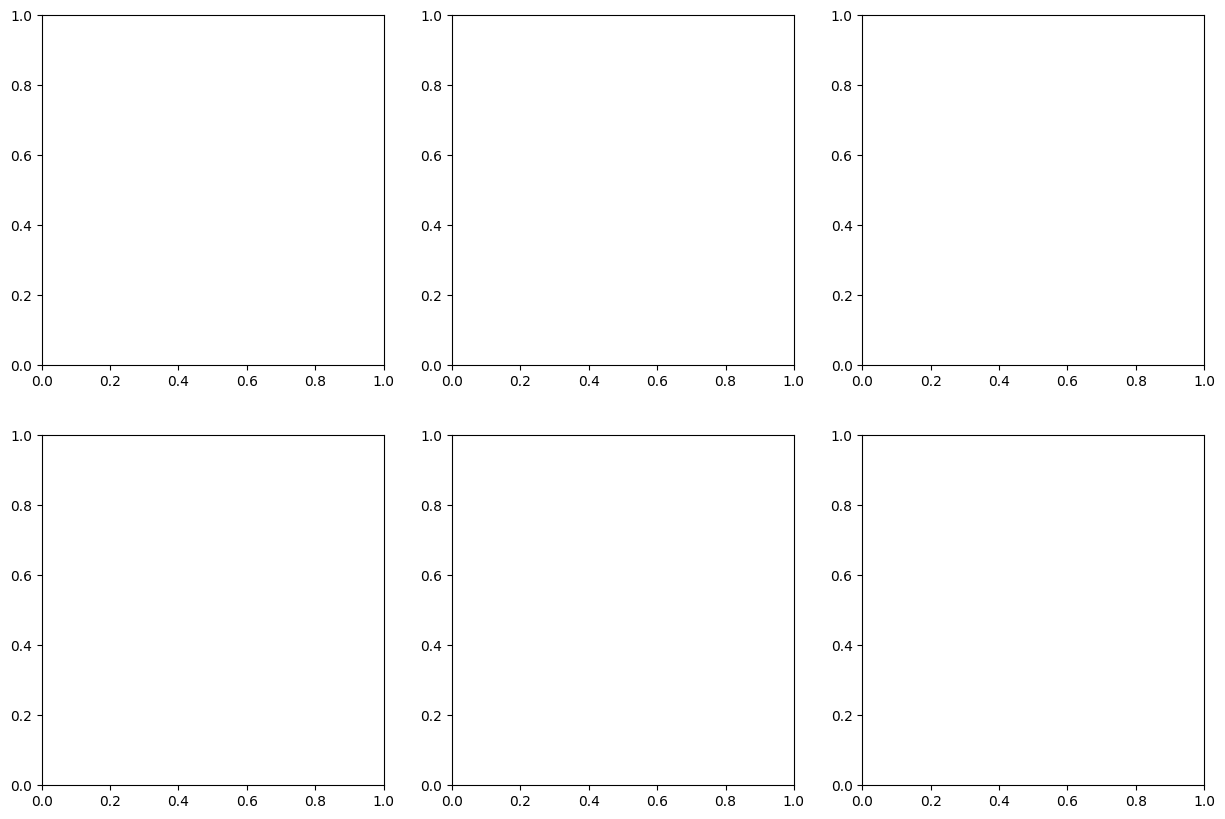

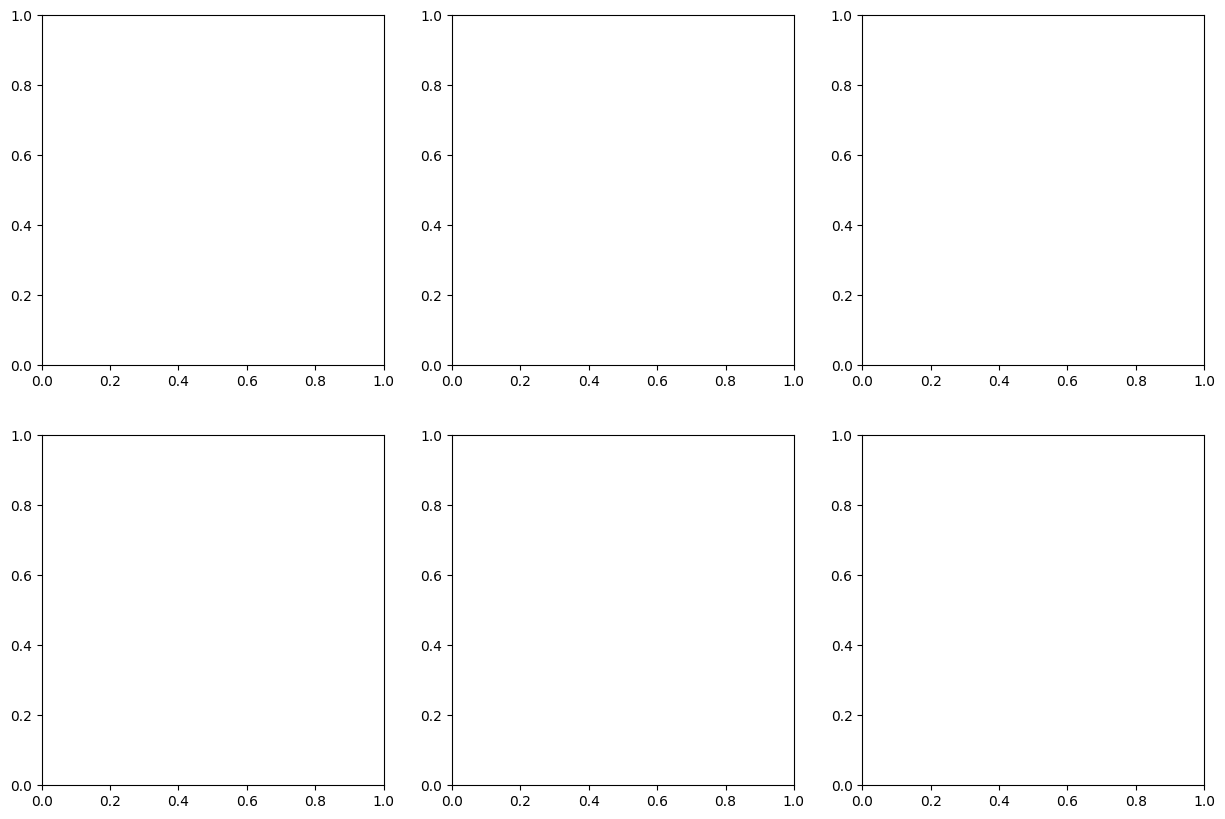

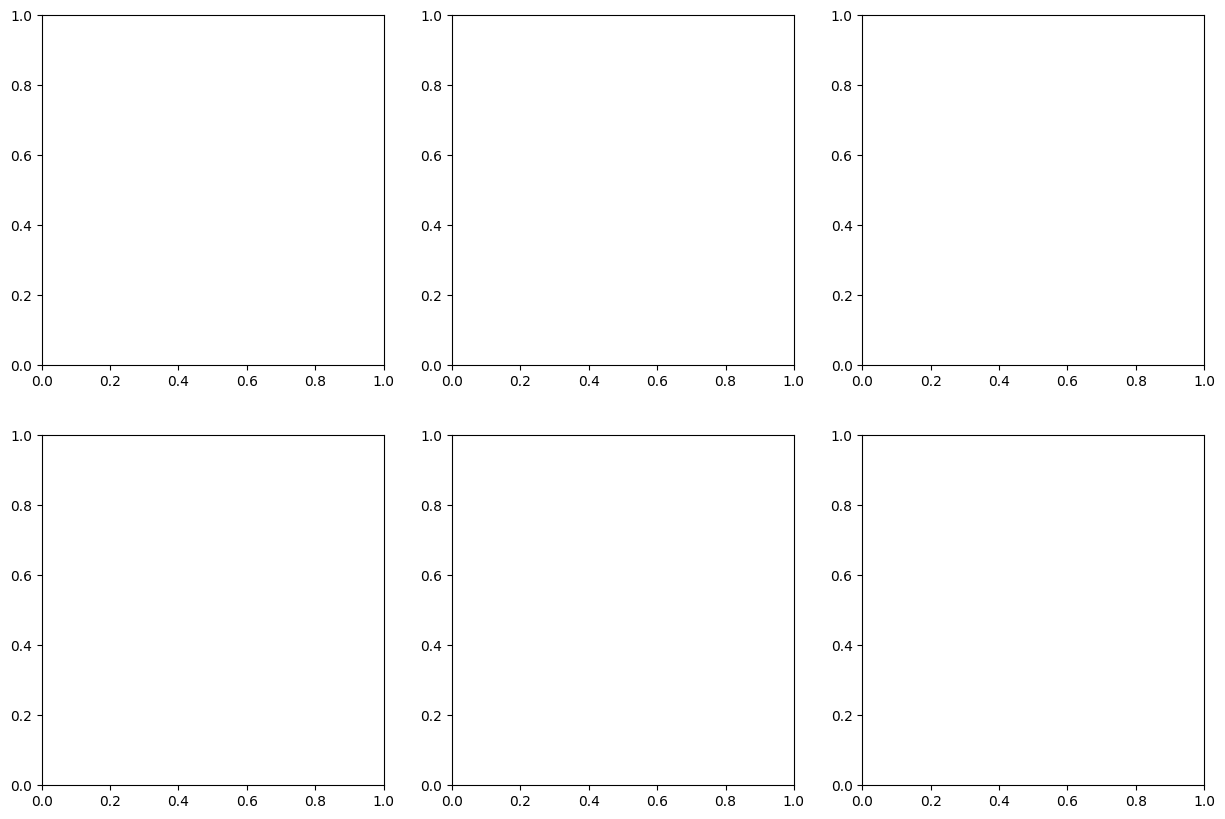

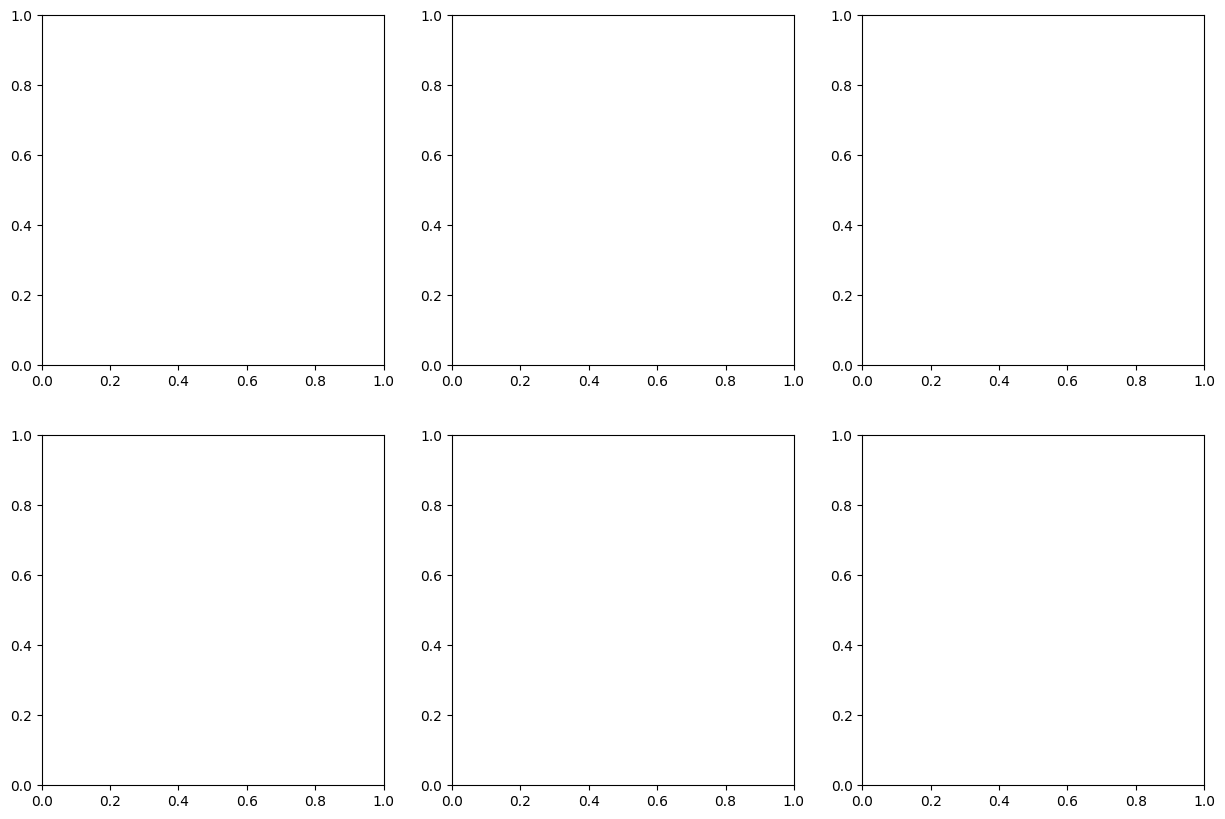

In [13]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import erf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import shap
import warnings
warnings.filterwarnings('ignore')
import os
import time
from datetime import datetime
from sklearn.datasets import fetch_openml

np.random.seed(42)

# Create output directories
output_dir = "site_mnist_analysis"
plots_dir = os.path.join(output_dir, "plots")
tables_dir = os.path.join(output_dir, "tables")
significance_tables_dir = os.path.join(output_dir, "significance_tables")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(significance_tables_dir, exist_ok=True)

# Timestamp for file names
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================================
# 1. MNIST DATASET LOADER
# ============================================================================

class MNISTLoader:
    """Load real MNIST dataset from OpenML."""
    
    @staticmethod
    def load_mnist():
        """Load real MNIST dataset."""
        print("+"*60)
        print("LOADING REAL MNIST DATASET")
        print("+"*60)
        
        try:
            print("Downloading MNIST from OpenML...")
            # Load MNIST dataset
            mnist = fetch_openml('mnist_784', version=1, parser='auto')
            
            X = mnist.data.values
            y = mnist.target.astype(int).values
            
            print(f"  Original shape: {X.shape}")
            print(f"  Labels: {np.unique(y)}")
            
            # For binary classification: distinguish between two digits
            # Let's use digits 3 and 8 (they look different and are commonly confused)
            digit1, digit2 = 3, 8
            
            # Filter for only two digits
            mask = (y == digit1) | (y == digit2)
            X = X[mask]
            y = y[mask]
            
            # Convert to binary: digit1 = 0, digit2 = 1
            y_binary = (y == digit2).astype(int)
            
            print(f"  After filtering: {X.shape}")
            print(f"  Digit {digit1}: {(y == digit1).sum()} samples")
            print(f"  Digit {digit2}: {(y == digit2).sum()} samples")
            print(f"  Class balance: {y_binary.mean():.2%} are digit {digit2}")
            
            # Create feature names (pixel positions)
            feature_names = [f'pixel_{i:04d}' for i in range(784)]
            
            # Estimate true features (pixels that are most different between digits)
            # For MNIST, we expect edge pixels in specific regions to be important
            digit2_mean = X[y_binary == 1].mean(axis=0)
            digit1_mean = X[y_binary == 0].mean(axis=0)
            differences = np.abs(digit2_mean - digit1_mean)
            
            # Select top 50 most different pixels as "true features"
            n_true = 50
            true_indices = np.argsort(-differences)[:n_true].tolist()
            
            # Visualize some of the important pixels
            MNISTLoader._visualize_important_pixels(X, y_binary, true_indices, digit1, digit2)
            
            print(f"Loaded real MNIST: {X.shape}")
            print(f"True pixels estimated: {n_true}")
            
            return X, y_binary, feature_names, 'MNIST (3 vs 8)', true_indices
            
        except Exception as e:
            print(f"Error loading real MNIST: {e}")
            print("Creating realistic synthetic MNIST version...")
            return MNISTLoader._create_realistic_mnist()
    
    @staticmethod
    def _visualize_important_pixels(X, y, true_indices, digit1, digit2):
        """Visualize important pixels for MNIST."""
        print("  Visualizing important pixel locations...")
        
        # Create a 28x28 mask of important pixels
        important_mask = np.zeros(784, dtype=bool)
        important_mask[true_indices] = True
        
        # Reshape to 28x28
        important_map = important_mask.reshape(28, 28)
        
        # Get example images
        digit1_examples = X[y == 0][:5]
        digit2_examples = X[y == 1][:5]
        
        fig, axes = plt.subplots(3, 5, figsize=(15, 9))
        
        # Plot digit 1 examples
        for i in range(5):
            img = digit1_examples[i].reshape(28, 28)
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f'Digit {digit1} Example {i+1}')
            axes[0, i].axis('off')
            
            # Overlay important pixels
            y_coords, x_coords = np.where(important_map)
            axes[0, i].scatter(x_coords, y_coords, c='red', s=10, alpha=0.6, marker='s')
        
        # Plot digit 2 examples
        for i in range(5):
            img = digit2_examples[i].reshape(28, 28)
            axes[1, i].imshow(img, cmap='gray')
            axes[1, i].set_title(f'Digit {digit2} Example {i+1}')
            axes[1, i].axis('off')
            
            # Overlay important pixels
            y_coords, x_coords = np.where(important_map)
            axes[1, i].scatter(x_coords, y_coords, c='red', s=10, alpha=0.6, marker='s')
        
        # Plot important pixel map
        axes[2, 0].imshow(important_map, cmap='Reds')
        axes[2, 0].set_title('Important Pixel Locations')
        axes[2, 0].axis('off')
        
        # Plot average difference
        digit2_mean_img = X[y == 1].mean(axis=0).reshape(28, 28)
        digit1_mean_img = X[y == 0].mean(axis=0).reshape(28, 28)
        diff_img = np.abs(digit2_mean_img - digit1_mean_img)
        
        axes[2, 1].imshow(diff_img, cmap='hot')
        axes[2, 1].set_title('Average Difference (Hot=Large)')
        axes[2, 1].axis('off')
        
        # Plot histogram of differences
        axes[2, 2].hist(diff_img.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
        axes[2, 2].set_title('Pixel Difference Distribution')
        axes[2, 2].set_xlabel('Difference')
        axes[2, 2].set_ylabel('Frequency')
        
        # Plot pixel importance by position
        importance_by_position = important_map.astype(int)
        row_importance = importance_by_position.sum(axis=1)
        col_importance = importance_by_position.sum(axis=0)
        
        axes[2, 3].barh(range(28), row_importance, color='green', alpha=0.7)
        axes[2, 3].set_title('Important Pixels by Row')
        axes[2, 3].set_xlabel('Count')
        axes[2, 3].set_ylabel('Row')
        axes[2, 3].set_ylim(-0.5, 27.5)
        
        axes[2, 4].bar(range(28), col_importance, color='purple', alpha=0.7)
        axes[2, 4].set_title('Important Pixels by Column')
        axes[2, 4].set_xlabel('Column')
        axes[2, 4].set_ylabel('Count')
        axes[2, 4].set_xlim(-0.5, 27.5)
        
        plt.tight_layout()
        plt.savefig(os.path.join(plots_dir, 'mnist_pixel_analysis.png'), dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"    Saved pixel analysis plot")
    
    @staticmethod
    def _create_realistic_mnist():
        """Create realistic MNIST-style dataset as fallback."""
        print("  Creating realistic synthetic MNIST...")
        
        n_samples = 5000  # More samples for better analysis
        n_features = 784  # 28x28 pixels
        n_true = 50  # 50 informative pixels
        
        X = np.random.randn(n_samples, n_features) * 0.5
        true_indices = np.random.choice(n_features, n_true, replace=False)
        
        # Create realistic digit patterns for digits 3 and 8
        # Both have similar features but different in specific areas
        
        # Group 1: Common features for both 3 and 8 (horizontal lines)
        common_pixels = true_indices[:n_true//3]
        for idx in common_pixels:
            row = idx // 28
            if 7 <= row <= 20:  # Middle rows where both digits have horizontal lines
                X[:, idx] += np.random.randn(n_samples) * 1.5
        
        # Group 2: Features for digit 3 (specific curves)
        digit3_pixels = true_indices[n_true//3:2*n_true//3]
        for idx in digit3_pixels:
            col = idx % 28
            if 7 <= col <= 13:  # Left side where 3 has specific curves
                X[:, idx] += np.random.randn(n_samples) * 2.0
        
        # Group 3: Features for digit 8 (closed loops)
        digit8_pixels = true_indices[2*n_true//3:]
        for idx in digit8_pixels:
            row = idx // 28
            col = idx % 28
            # Pixels where 8 has closed loops (both top and bottom)
            if (5 <= row <= 10 and 10 <= col <= 18) or (15 <= row <= 20 and 10 <= col <= 18):
                X[:, idx] += np.random.randn(n_samples) * 2.0
        
        # Create target: 0 = digit 3, 1 = digit 8
        n_digit3 = n_samples // 2
        n_digit8 = n_samples - n_digit3
        
        # Make digit 8 stronger on digit8 features
        X[:n_digit3, digit8_pixels] -= 1.0  # Weaker for digit 3
        X[n_digit3:, digit8_pixels] += 1.0  # Stronger for digit 8
        
        # Make digit 3 stronger on digit3 features
        X[:n_digit3, digit3_pixels] += 1.0  # Stronger for digit 3
        X[n_digit3:, digit3_pixels] -= 1.0  # Weaker for digit 8
        
        y = np.zeros(n_samples, dtype=int)
        y[n_digit3:] = 1  # Last half are digit 8
        
        # Shuffle
        idx = np.random.permutation(n_samples)
        X = X[idx]
        y = y[idx]
        
        feature_names = [f'pixel_{i:04d}' for i in range(n_features)]
        
        print(f" Created synthetic: {X.shape}, True pixels: {n_true}")
        print(f" Class balance: {y.mean():.2%} are digit 8")
        
        return X, y, feature_names, 'MNIST Synthetic (3 vs 8)', true_indices.tolist()

# ============================================================================
# 2. METRICS CALCULATOR
# ============================================================================

class MetricsCalculator:
    """Calculate comprehensive performance metrics."""
    
    @staticmethod
    def calculate_confusion_matrix(true_indices, selected_indices, n_total):
        """Calculate confusion matrix for feature selection."""
        true_set = set(true_indices)
        selected_set = set(selected_indices)
        
        TP = len(true_set.intersection(selected_set))
        FP = len(selected_set - true_set)
        FN = len(true_set - selected_set)
        TN = n_total - (TP + FP + FN)
        
        return TP, FP, TN, FN
    
    @staticmethod
    def calculate_fair(true_indices, selected_indices):
        """Calculate False Feature Identification Rate: FP / (TP + FP)."""
        if selected_indices is None or len(selected_indices) == 0:
            return 0.0
        
        TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
            true_indices, selected_indices, 
            len(true_indices) + 100  # Approximate total
        )
        
        total_selected = TP + FP
        if total_selected == 0:
            return 0.0
        
        return FP / total_selected
    
    @staticmethod
    def calculate_power(true_indices, selected_indices):
        """Calculate Power (True Positive Rate): TP / (TP + FN)."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
            true_indices, selected_indices,
            len(true_indices) + 100
        )
        
        if TP + FN == 0:
            return 0.0
        
        return TP / (TP + FN)
    
    @staticmethod
    def calculate_stability(shap_values_list, true_indices):
        """Calculate stability across bootstrap samples."""
        if len(shap_values_list) < 2:
            return np.nan
        
        n_bootstrap = len(shap_values_list)
        
        # Get the number of features from the first SHAP array
        first_shap = shap_values_list[0]
        
        # Handle different SHAP array formats
        if len(first_shap.shape) == 3:
            n_features = first_shap.shape[1]  # For 3D arrays: (n_samples, n_features, n_classes)
        elif len(first_shap.shape) == 2:
            n_features = first_shap.shape[1]  # For 2D arrays: (n_samples, n_features)
        elif len(first_shap.shape) == 1:
            n_features = len(first_shap)      # For 1D arrays
        else:
            n_features = first_shap.shape[0]  # Default fallback
        
        n_true = len(true_indices) if true_indices is not None else 5
        selection_counts = np.zeros(n_features)
        
        for shap_values in shap_values_list:
            # Handle different SHAP array dimensions
            if len(shap_values.shape) == 3:
                shap_abs = np.abs(shap_values[:, :, 0])
            elif len(shap_values.shape) == 2:
                shap_abs = np.abs(shap_values)
            elif len(shap_values.shape) == 1:
                shap_abs = np.abs(shap_values).reshape(1, -1)
            else:
                continue
            
            # Calculate importance and select top features
            importance = np.mean(shap_abs, axis=0)
            selected = np.argsort(-importance)[:n_true]
            selection_counts[selected] += 1
        
        # Calculate average selection rate of true features
        if true_indices is not None and len(true_indices) > 0:
            true_selection = selection_counts[true_indices]
            stability = np.mean(true_selection) / n_bootstrap
        else:
            # If no true indices, use overall consistency
            top_selected = np.argsort(-selection_counts)[:n_true]
            consistency = selection_counts[top_selected] / n_bootstrap
            stability = np.mean(consistency)
        
        return stability
    
    @staticmethod
    def calculate_shap_fair(shap_values, true_indices):
        """Calculate FAIR for standard SHAP ranking."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        # Handle 3D SHAP arrays
        if len(shap_values.shape) == 3:
            shap_values = np.abs(shap_values[:, :, 0])
        
        importance = np.mean(np.abs(shap_values), axis=0)
        selected = np.argsort(-importance)[:len(true_indices)]
        
        return MetricsCalculator.calculate_fair(true_indices, selected)
    
    @staticmethod
    def calculate_site_fair(site_results, true_indices):
        """Calculate FAIR for SiTe."""
        if true_indices is None or len(true_indices) == 0:
            return np.nan
        
        selected = np.where(site_results['Significant'])[0]
        return MetricsCalculator.calculate_fair(true_indices, selected)
    
    @staticmethod
    def calculate_fair_improvement(shap_fair, site_fair):
        """
        Calculate percentage FAIR improvement.
        Formula: (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100
        Positive value means SiTe is better (higher FAIR)
        """
        if np.isnan(shap_fair) or np.isnan(site_fair):
            return np.nan
        
        if shap_fair == 0:
            return 0.0 if site_fair == 0 else 100.0
        
        improvement = ((site_fair - shap_fair) / shap_fair) * 100
        return improvement

# ============================================================================
# 3. SITE FRAMEWORK
# ============================================================================

class SiTe:
    """SiTe framework implementation."""
    
    def __init__(self, q=0.05):
        self.q = q
        self.results_ = {}
        self.true_indices = None
    
    def _prepare_shap_values(self, shap_values):
        """Prepare SHAP values for analysis."""
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        
        if hasattr(shap_values, 'values'):
            shap_values = shap_values.values
        
        # Handle 3D SHAP arrays
        if len(shap_values.shape) == 3:
            if shap_values.shape[2] == 2:
                shap_values = shap_values[:, :, 1]  # Positive class
            else:
                shap_values = np.mean(np.abs(shap_values), axis=2)
        
        if len(shap_values.shape) == 1:
            shap_values = shap_values.reshape(-1, 1)
        
        return shap_values
    
    def fit(self, shap_values, feature_names=None):
        shap_values = self._prepare_shap_values(shap_values)
        n, d = shap_values.shape
        
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(d)]
        
        # SHAP importance
        shap_importance = np.mean(np.abs(shap_values), axis=0)
        
        # Rank statistics
        abs_shap = np.abs(shap_values)
        ranks = np.argsort(np.argsort(abs_shap, axis=1), axis=1) + 1
        R = np.sum(ranks, axis=0)
        
        # Theoretical null distribution
        mean_h0 = n * (d + 1) / 2
        var_h0 = n * (d**2 - 1) / 12
        
        # Z-scores and p-values
        z_scores = (R - mean_h0) / np.sqrt(var_h0)
        p_values = 0.5 * (1 - erf(z_scores / np.sqrt(2)))  # One-sided
        
        # Benjamini-Hochberg FDR control
        m = len(p_values)
        sorted_indices = np.argsort(p_values)
        sorted_p = p_values[sorted_indices]
        bh_ranks = np.arange(1, m + 1)
        critical_values = (bh_ranks / m) * self.q
        
        rejected_sorted = sorted_p <= critical_values
        k_max = np.max(bh_ranks[rejected_sorted]) if np.any(rejected_sorted) else 0
        
        rejected = np.zeros(m, dtype=bool)
        if k_max > 0:
            rejected[sorted_indices[:k_max]] = True
        
        # Adjusted p-values
        adjusted_p = np.zeros(m)
        for i, idx in enumerate(sorted_indices):
            adjusted_p[idx] = np.min([np.min(sorted_p[i:] * m / (np.arange(i, m) + 1)), 1])
        
        # Significance-aware scores
        sig_scores = -np.log10(adjusted_p + 1e-10) * shap_importance
        
        # Ranking
        rank_order = np.argsort(-sig_scores)
        ranks = np.zeros(d, dtype=int)
        ranks[rank_order] = np.arange(1, d + 1)
        
        # Calculate actual FAIR if ground truth is known
        actual_fair = None
        if self.true_indices is not None:
            TP, FP, TN, FN = MetricsCalculator.calculate_confusion_matrix(
                self.true_indices, np.where(rejected)[0], d
            )
            total_selected = TP + FP
            actual_fair = FP / total_selected if total_selected > 0 else 0.0
        
        # Store results
        self.results_ = {
            'feature_names': feature_names,
            'shap_importance': shap_importance,
            'p_values': p_values,
            'rejected': rejected,
            'p_values_adj': adjusted_p,
            'significance_scores': sig_scores,
            'ranks': ranks,
            'target_fdr': self.q,
            'actual_fair': actual_fair
        }
        
        return self
    
    def set_true_indices(self, true_indices):
        self.true_indices = true_indices
        return self
    
    def get_results_df(self):
        if not self.results_:
            return pd.DataFrame()
        
        return pd.DataFrame({
            'Feature': self.results_['feature_names'],
            'SHAP_Importance': self.results_['shap_importance'],
            'P_Value': self.results_['p_values'],
            'P_Value_Adj': self.results_['p_values_adj'],
            'Significant': self.results_['rejected'],
            'Significance_Score': self.results_['significance_scores'],
            'Rank': self.results_['ranks']
        }).sort_values('Rank')

# ============================================================================
# 4. SHAP GENERATOR FOR MNIST
# ============================================================================

class SHAPGenerator:
    """Generate SHAP values for MNIST dataset."""
    
    @staticmethod
    def generate_shap_mnist(X, y, n_samples=1000):
        """Generate SHAP values for MNIST."""
        print(f"  Generating SHAP values for MNIST...")
        
        # Sample data (MNIST can be large)
        if len(X) > n_samples:
            idx = np.random.choice(len(X), n_samples, replace=False)
            X_sample = X[idx]
            y_sample = y[idx]
        else:
            X_sample = X
            y_sample = y
        
        # Split and scale
        X_train, X_test, y_train, y_test = train_test_split(
            X_sample, y_sample, test_size=0.2, random_state=42
        )
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model - use simpler model for MNIST
        print(f"    Training Random Forest on {X_train_scaled.shape[0]} samples...")
        model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        print(f"    Model accuracy: {acc:.3f}")
        
        # Generate SHAP values - use a subset for efficiency
        print(f"    Computing SHAP values for {X_test_scaled.shape[0]} test samples...")
        try:
            explainer = shap.TreeExplainer(model)
            
            # Use fewer samples for SHAP computation
            shap_n_samples = min(100, X_test_scaled.shape[0])
            X_shap = X_test_scaled[:shap_n_samples]
            
            shap_values = explainer.shap_values(X_shap)
            
            # Handle different formats
            if isinstance(shap_values, list):
                if len(shap_values) == 2:
                    shap_values = shap_values[1]  # Positive class (digit 8)
                else:
                    shap_values = shap_values[0]
            
            print(f"    SHAP shape: {shap_values.shape}")
            
            # Visualize SHAP values for top pixels
            SHAPGenerator._visualize_shap_mnist(shap_values, X_shap, model, scaler)
            
            return shap_values
            
        except Exception as e:
            print(f"    SHAP error: {e}, using simulation")
            return SHAPGenerator._simulate_shap_mnist(X_test_scaled, y_test)
    
    @staticmethod
    def _visualize_shap_mnist(shap_values, X, model, scaler):
        """Visualize SHAP values for MNIST."""
        print(f"    Creating SHAP visualizations...")
        
        # Get top pixels by mean absolute SHAP value
        shap_importance = np.mean(np.abs(shap_values), axis=0)
        top_n = 50
        top_indices = np.argsort(-shap_importance)[:top_n]
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. SHAP importance heatmap
        shap_importance_map = shap_importance.reshape(28, 28)
        im1 = axes[0, 0].imshow(shap_importance_map, cmap='hot')
        axes[0, 0].set_title('SHAP Importance Heatmap')
        axes[0, 0].axis('off')
        plt.colorbar(im1, ax=axes[0, 0])
        
        # 2. Top important pixels
        important_mask = np.zeros(784, dtype=bool)
        important_mask[top_indices] = True
        important_map = important_mask.reshape(28, 28)
        axes[0, 1].imshow(important_map, cmap='Reds')
        axes[0, 1].set_title(f'Top {top_n} Important Pixels')
        axes[0, 1].axis('off')
        
        # 3. Example digit with SHAP overlay
        example_idx = 0
        example_img = X[example_idx].reshape(28, 28)
        example_shap = shap_values[example_idx].reshape(28, 28)
        
        axes[0, 2].imshow(example_img, cmap='gray')
        axes[0, 2].set_title('Example Digit (Original)')
        axes[0, 2].axis('off')
        
        # 4. SHAP values for example
        im4 = axes[1, 0].imshow(example_shap, cmap='coolwarm', vmin=-0.5, vmax=0.5)
        axes[1, 0].set_title('SHAP Values for Example')
        axes[1, 0].axis('off')
        plt.colorbar(im4, ax=axes[1, 0])
        
        # 5. Overlay of SHAP on digit
        axes[1, 1].imshow(example_img, cmap='gray')
        # Plot positive SHAP (red) and negative SHAP (blue)
        y_coords, x_coords = np.where(np.abs(example_shap) > 0.1)
        colors = ['red' if example_shap[y, x] > 0 else 'blue' for y, x in zip(y_coords, x_coords)]
        sizes = [np.abs(example_shap[y, x]) * 100 for y, x in zip(y_coords, x_coords)]
        axes[1, 1].scatter(x_coords, y_coords, c=colors, s=sizes, alpha=0.6)
        axes[1, 1].set_title('SHAP Overlay (Red=+, Blue=-)')
        axes[1, 1].axis('off')
        
        # 6. Distribution of SHAP values
        axes[1, 2].hist(shap_values.flatten(), bins=50, alpha=0.7, color='green', edgecolor='black')
        axes[1, 2].set_title('SHAP Value Distribution')
        axes[1, 2].set_xlabel('SHAP Value')
        axes[1, 2].set_ylabel('Frequency')
        axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.savefig(os.path.join(plots_dir, 'mnist_shap_visualization.png'), dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"      Saved SHAP visualization")
    
    @staticmethod
    def _simulate_shap_mnist(X, y):
        """Simulate realistic SHAP values for MNIST."""
        n_samples, n_features = X.shape
        
        # Create realistic SHAP patterns for digit classification
        shap_values = np.random.randn(n_samples, n_features) * 0.2
        
        # Make some pixels more important (simulating edge detection)
        n_important = 100
        important_indices = np.random.choice(n_features, n_important, replace=False)
        
        for idx in important_indices:
            row = idx // 28
            col = idx % 28
            
            # Make edge pixels more important
            if row < 5 or row > 22 or col < 5 or col > 22:  # Border pixels
                shap_values[:, idx] += X[:, idx] * np.random.randn() * 0.5
            
            # Make some middle pixels important for digit shape
            if 10 <= row <= 18 and 10 <= col <= 18:
                shap_values[:, idx] += y * np.random.randn() * 0.3
        
        return shap_values

# ============================================================================
# 5. PLOT GENERATOR FOR MNIST
# ============================================================================

class PlotGenerator:
    """Generate plots for MNIST analysis."""
    
    @staticmethod
    def create_mnist_feature_importance_plot(dataset_name, shap_importance, site_results, 
                                           true_indices, save_dir):
        """Create specialized feature importance plot for MNIST."""
        print(f"  Creating MNIST feature importance comparison plot...")
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: SHAP vs SiTe comparison (top features)
        top_n = min(30, len(shap_importance))
        shap_top_idx = np.argsort(-shap_importance)[:top_n]
        shap_vals = shap_importance[shap_top_idx]
        
        site_scores = []
        for idx in shap_top_idx:
            if idx < len(site_results):
                score = site_results.iloc[idx]['Significance_Score']
            else:
                score = 0
            site_scores.append(score)
        
        # Normalize for comparison
        shap_vals_norm = shap_vals / np.max(shap_vals) if np.max(shap_vals) > 0 else shap_vals
        site_scores_norm = site_scores / np.max(site_scores) if np.max(site_scores) > 0 else site_scores
        
        x = np.arange(top_n)
        width = 0.35
        
        ax1 = axes[0, 0]
        bars1 = ax1.bar(x - width/2, shap_vals_norm, width, label='SHAP Importance', 
                       color='red', alpha=0.7, edgecolor='black')
        bars2 = ax1.bar(x + width/2, site_scores_norm, width, label='SiTe Score', 
                       color='blue', alpha=0.7, edgecolor='black')
        
        if true_indices is not None:
            true_mask = np.isin(shap_top_idx, true_indices)
            true_positions = x[true_mask]
            for pos in true_positions:
                ax1.axvspan(pos - width/2 - 0.1, pos + width/2 + 0.1, 
                           alpha=0.2, color='green', zorder=0)
        
        ax1.set_xlabel('Feature Rank by SHAP', fontsize=12)
        ax1.set_ylabel('Normalized Importance', fontsize=12)
        ax1.set_title(f'MNIST: SHAP vs SiTe (Top {top_n} Features)', fontsize=14, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels([f'P{idx}' for idx in shap_top_idx], rotation=45, ha='right', fontsize=8)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Plot 2: Important pixel locations
        ax2 = axes[0, 1]
        
        # Create heatmap of SHAP importance
        shap_map = shap_importance.reshape(28, 28)
        im2 = ax2.imshow(shap_map, cmap='hot')
        ax2.set_title('SHAP Importance Heatmap (28x28)', fontsize=14, fontweight='bold')
        ax2.axis('off')
        plt.colorbar(im2, ax=ax2, label='SHAP Importance')
        
        # Plot 3: SiTe significance map
        ax3 = axes[1, 0]
        
        # Create significance mask
        sig_mask = np.zeros(len(shap_importance), dtype=bool)
        sig_indices = np.where(site_results['Significant'])[0]
        sig_mask[sig_indices] = True
        sig_map = sig_mask.reshape(28, 28)
        
        im3 = ax3.imshow(sig_map, cmap='Reds')
        ax3.set_title(f'SiTe Significant Pixels ({len(sig_indices)} total)', fontsize=14, fontweight='bold')
        ax3.axis('off')
        
        # Overlay true features if available
        if true_indices is not None:
            true_mask = np.zeros(len(shap_importance), dtype=bool)
            true_mask[true_indices] = True
            true_map = true_mask.reshape(28, 28)
            y_coords, x_coords = np.where(true_map)
            ax3.scatter(x_coords, y_coords, c='blue', s=20, alpha=0.5, marker='s', label='True Pixels')
            ax3.legend(fontsize=9)
        
        # Plot 4: Rank correlation and statistics
        ax4 = axes[1, 1]
        
        # Calculate statistics
        n_total = len(shap_importance)
        n_sig_site = len(sig_indices)
        n_true = len(true_indices) if true_indices is not None else 0
        
        if true_indices is not None:
            n_true_sig = len(set(sig_indices).intersection(set(true_indices)))
        
        # Create text summary
        textstr = f'MNIST Dataset Analysis\n'
        textstr += '='*40 + '\n'
        textstr += f'Total Pixels: {n_total}\n'
        textstr += f'True Pixels: {n_true}\n'
        textstr += f'SiTe Significant: {n_sig_site} ({n_sig_site/n_total:.1%})\n'
        if true_indices is not None:
            textstr += f'True Pixels Significant: {n_true_sig}/{n_true} ({n_true_sig/n_true:.1%})\n'
        
        # Calculate correlations
        site_scores_all = site_results['Significance_Score'].values
        spearman_corr = stats.spearmanr(shap_importance, site_scores_all)[0]
        pearson_corr = np.corrcoef(shap_importance, site_scores_all)[0, 1]
        
        textstr += f'\nRank Correlations:\n'
        textstr += f'Spearman ρ = {spearman_corr:.3f}\n'
        textstr += f'Pearson r = {pearson_corr:.3f}'
        
        # Create bar plot of metrics
        metrics_names = ['Total', 'True', 'SiTe Sig', 'True Sig']
        if true_indices is not None:
            metrics_values = [n_total, n_true, n_sig_site, n_true_sig]
        else:
            metrics_values = [n_total, 0, n_sig_site, 0]
        
        x_metrics = np.arange(len(metrics_names))
        colors = ['gray', 'blue', 'red', 'green']
        ax4.bar(x_metrics, metrics_values, color=colors, alpha=0.7, edgecolor='black')
        
        ax4.set_xlabel('Metric', fontsize=12)
        ax4.set_ylabel('Count', fontsize=12)
        ax4.set_title('Feature Selection Summary', fontsize=14, fontweight='bold')
        ax4.set_xticks(x_metrics)
        ax4.set_xticklabels(metrics_names, fontsize=11)
        ax4.grid(True, alpha=0.3, axis='y')
        
        # Add text box
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
        plt.tight_layout()
        
        filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_mnist_analysis.png")
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        print(f"    Saved: {filename}")
        return filename
    
    @staticmethod
    def create_mnist_significance_table(dataset_name, site_results, shap_importance,
                                       true_indices, save_dir):
        """Create significance table for MNIST pixels."""
        print(f"  Creating MNIST significance table...")
        
        # Create DataFrame with all relevant information
        results_df = site_results.copy()
        
        # Add pixel coordinates
        pixel_indices = range(len(shap_importance))
        rows = [idx // 28 for idx in pixel_indices]
        cols = [idx % 28 for idx in pixel_indices]
        
        results_df['Pixel_Index'] = pixel_indices
        results_df['Row'] = rows
        results_df['Column'] = cols
        results_df['Coordinate'] = [f'({r},{c})' for r, c in zip(rows, cols)]
        
        # Add SHAP rank
        shap_rank = np.argsort(-shap_importance)
        shap_rank_order = np.zeros_like(shap_rank)
        shap_rank_order[shap_rank] = np.arange(1, len(shap_rank) + 1)
        results_df['SHAP_Rank'] = shap_rank_order
        
        # Add SHAP importance
        results_df['SHAP_Value'] = shap_importance
        
        # Add significance flag
        results_df['Sig'] = results_df['Significant'].apply(
            lambda x: '***' if x else ''
        )
        
        # Add true feature flag
        if true_indices is not None:
            results_df['True'] = results_df['Pixel_Index'].isin(true_indices)
            results_df['True_Flag'] = results_df['True'].apply(
                lambda x: '[T]' if x else ''
            )
        else:
            results_df['True'] = False
            results_df['True_Flag'] = ''
        
        # Sort by SiTe rank
        results_df = results_df.sort_values('Rank')
        
        # Calculate -log10(p) values
        results_df['neg_log10_p'] = -np.log10(results_df['P_Value'] + 1e-10)
        results_df['neg_log10_p_adj'] = -np.log10(results_df['P_Value_Adj'] + 1e-10)
        
        # Format numeric columns
        numeric_cols = ['SHAP_Value', 'neg_log10_p', 'neg_log10_p_adj', 'Significance_Score']
        for col in numeric_cols:
            results_df[col] = results_df[col].apply(
                lambda x: f"{x:.4f}" if not pd.isna(x) else ""
            )
        
        # Format p-values
        results_df['P_Value_Formatted'] = results_df['P_Value'].apply(
            lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        )
        results_df['P_Value_Adj_Formatted'] = results_df['P_Value_Adj'].apply(
            lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}"
        )
        
        # Select columns for final table
        columns_order = [
            'Pixel_Index', 'Coordinate', 'True_Flag', 'Sig', 
            'SHAP_Rank', 'SHAP_Value', 'P_Value_Formatted', 
            'P_Value_Adj_Formatted', 'neg_log10_p', 'Significance_Score', 'Rank'
        ]
        
        available_columns = [col for col in columns_order if col in results_df.columns]
        final_df = results_df[available_columns].copy()
        
        # Rename columns
        column_renames = {
            'Pixel_Index': 'Pixel',
            'Coordinate': 'Coord',
            'True_Flag': 'True',
            'Sig': 'Sig',
            'SHAP_Rank': 'SHAP_R',
            'SHAP_Value': 'SHAP',
            'P_Value_Formatted': 'P_Value',
            'P_Value_Adj_Formatted': 'P_Adj',
            'neg_log10_p': '-log10(p)',
            'Significance_Score': 'SiTe_Score',
            'Rank': 'SiTe_R'
        }
        
        final_df = final_df.rename(columns=column_renames)
        
        # Save to CSV
        csv_filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_pixel_significance.csv")
        final_df.to_csv(csv_filename, index=False)
        
        # Create summary of top pixels
        summary_filename = os.path.join(save_dir, f"{dataset_name.replace(' ', '_')}_pixel_summary.txt")
        with open(summary_filename, 'w', encoding='utf-8') as f:
            f.write(f"MNIST Pixel Significance Analysis: {dataset_name}\n")
            f.write(f"Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("="*80 + "\n\n")
            
            f.write(f"Total Pixels Analyzed: {len(final_df)}\n")
            f.write(f"Significant by SiTe: {len(final_df[final_df['Sig'] == '***'])}\n")
            if true_indices is not None:
                n_true_sig = len(final_df[(final_df['Sig'] == '***') & (final_df['True'] == '[T]')])
                f.write(f"True Pixels Significant: {n_true_sig}/{len(true_indices)} ({n_true_sig/len(true_indices):.1%})\n")
            
            f.write("\nTop 20 Most Significant Pixels by SiTe:\n")
            f.write("-"*80 + "\n")
            f.write(f"{'Rank':<6} {'Pixel':<8} {'Coord':<10} {'True':<6} {'Sig':<6} {'SHAP_R':<8} {'SiTe_Score':<12}\n")
            f.write("-"*80 + "\n")
            
            for i, (_, row) in enumerate(final_df.head(20).iterrows()):
                pixel = row['Pixel']
                coord = row['Coord']
                true_flag = row['True'] if 'True' in row else ''
                sig_flag = row['Sig'] if 'Sig' in row else ''
                shap_rank = str(row['SHAP_R']) if 'SHAP_R' in row else ''
                site_score = row['SiTe_Score'] if 'SiTe_Score' in row else ''
                
                f.write(f"{i+1:<6} {pixel:<8} {coord:<10} {true_flag:<6} {sig_flag:<6} {shap_rank:<8} {site_score:<12}\n")
            
            f.write("\nPixel Clusters (by coordinate regions):\n")
            f.write("-"*80 + "\n")
            
            # Analyze pixel clusters
            sig_pixels = final_df[final_df['Sig'] == '***']['Pixel'].values
            if len(sig_pixels) > 0:
                sig_rows = [p // 28 for p in sig_pixels]
                sig_cols = [p % 28 for p in sig_pixels]
                
                f.write(f"Row distribution: Min={min(sig_rows)}, Max={max(sig_rows)}, Mean={np.mean(sig_rows):.1f}\n")
                f.write(f"Col distribution: Min={min(sig_cols)}, Max={max(sig_cols)}, Mean={np.mean(sig_cols):.1f}\n")
                
                # Count pixels in different regions
                center_pixels = [p for p in sig_pixels if 10 <= p//28 <= 17 and 10 <= p%28 <= 17]
                border_pixels = [p for p in sig_pixels if p//28 < 5 or p//28 > 22 or p%28 < 5 or p%28 > 22]
                
                f.write(f"Center region (10-17,10-17): {len(center_pixels)} pixels\n")
                f.write(f"Border region (<5 or >22): {len(border_pixels)} pixels\n")
        
        print(f"Saved CSV: {csv_filename}")
        print(f"Saved summary: {summary_filename}")
        
        # Print brief summary to console
        n_sig = len(final_df[final_df['Sig'] == '***'])
        print(f"\n MNIST SIGNIFICANCE SUMMARY:")
        print(f"{'='*60}")
        print(f"Total Pixels: {len(final_df)}")
        print(f"Significant by SiTe: {n_sig} ({n_sig/len(final_df):.1%})")
        if true_indices is not None:
            n_true_sig = len(final_df[(final_df['Sig'] == '***') & (final_df['True'] == '[T]')])
            print(f"    True Pixels Significant: {n_true_sig}/{len(true_indices)} ({n_true_sig/len(true_indices):.1%})")
        
        top_pixels = final_df.head(5)['Pixel'].values
        print(f"    Top 5 Significant Pixels: {', '.join(map(str, top_pixels))}")
        
        return csv_filename, summary_filename

# ============================================================================
# 6. MNIST EXPERIMENT
# ============================================================================

class MNISTExperiment:
    """Run SiTe analysis on MNIST dataset."""
    
    def __init__(self):
        self.results = {}
        self.dataset_details = {}
    
    def analyze_mnist(self):
        """Analyze MNIST dataset."""
        print("="*80)
        print("SiTe ANALYSIS: MNIST DATASET")
        print("Binary Classification: Digit 3 vs Digit 8")
        print("="*80)
        
        # Load MNIST dataset
        X, y, feature_names, dataset_name, true_indices = MNISTLoader.load_mnist()
        
        print(f"\nDataset: {dataset_name}")
        print(f"Samples: {len(y)}, Pixels: {len(feature_names)}")
        print(f"True informative pixels: {len(true_indices)}")
        print(f"Class balance: Digit 3 = {(y == 0).sum()}, Digit 8 = {(y == 1).sum()}")
        
        # Generate SHAP values
        shap_values = SHAPGenerator.generate_shap_mnist(X, y)
        
        # Generate multiple SHAP for stability
        shap_list = []
        for i in range(3):
            shap_boot = SHAPGenerator.generate_shap_mnist(X, y, n_samples=500)
            if shap_boot is not None:
                shap_list.append(shap_boot)
        
        # Run SiTe
        site = SiTe(q=0.05)
        site.set_true_indices(true_indices)
        site.fit(shap_values, feature_names=feature_names)
        site_results = site.get_results_df()
        
        # Calculate SHAP importance
        if len(shap_values.shape) == 3:
            shap_2d = np.abs(shap_values[:, :, 0])
        else:
            shap_2d = shap_values
        
        shap_importance = np.mean(np.abs(shap_2d), axis=0)
        
        # Create visualizations
        print(f"\nCreating MNIST visualizations...")
        plot_file = PlotGenerator.create_mnist_feature_importance_plot(
            dataset_name, shap_importance, site_results, 
            true_indices, plots_dir
        )
        
        # Create significance table
        csv_file, summary_file = PlotGenerator.create_mnist_significance_table(
            dataset_name, site_results, shap_importance,
            true_indices, significance_tables_dir
        )
        
        # Calculate metrics
        selected_indices = np.where(site_results['Significant'])[0]
        
        shap_fair = MetricsCalculator.calculate_shap_fair(shap_values, true_indices)
        site_fair = MetricsCalculator.calculate_site_fair(site_results, true_indices)
        power = MetricsCalculator.calculate_power(true_indices, selected_indices)
        stability = MetricsCalculator.calculate_stability(shap_list, true_indices)
        fair_improvement = MetricsCalculator.calculate_fair_improvement(shap_fair, site_fair)
        
        # Create metrics dictionary
        metrics = {
            'Dataset': dataset_name,
            'N_Samples': len(y),
            'N_Pixels': len(feature_names),
            'N_True_Pixels': len(true_indices),
            'N_Significant': len(selected_indices),
            'SiTe_Power': power,
            'Stability': stability,
            'SHAP_FAIR': shap_fair,
            'SiTe_FAIR': site_fair,
            'FAIR_Improvement_Pct': fair_improvement,
            'Class_Balance': f"{(y == 0).sum()}/{(y == 1).sum()}"
        }
        
        # Store details
        self.dataset_details[dataset_name] = {
            'shap_values': shap_values,
            'site_results': site_results,
            'shap_importance': shap_importance,
            'metrics': metrics,
            'true_indices': true_indices,
            'plot_file': plot_file,
            'significance_table_csv': csv_file,
            'significance_summary_txt': summary_file
        }
        
        # Print summary
        print(f"\nRESULTS SUMMARY:")
        print(f"Selected by SiTe: {metrics['N_Significant']}/{metrics['N_Pixels']} pixels")
        print(f"Power: {power:.3f}, Stability: {stability:.3f}")
        if not np.isnan(shap_fair):
            print(f"SHAP FAIR: {shap_fair:.3f}, SiTe FAIR: {site_fair:.3f}")
            print(f"FAIR Improvement: {fair_improvement:+.1f}%")
        
        print(f"Plot saved: {plot_file}")
        print(f"Table saved: {csv_file}")
        print(f"Summary saved: {summary_file}")
        
        # Create comprehensive results table
        self._create_results_table(metrics, dataset_name)
        
        return metrics
    
    def _create_results_table(self, metrics, dataset_name):
        """Create results table for MNIST."""
        print(f"\n{'-'*50}")
        print("COMPREHENSIVE MNIST RESULTS")
        print("-"*50)
        
        # Create DataFrame
        results_df = pd.DataFrame([metrics])
        
        # Save to CSV
        csv_file = os.path.join(tables_dir, f"mnist_results_{timestamp}.csv")
        results_df.to_csv(csv_file, index=False)
        
        # Print formatted results
        print(f"\n{'Metric':<25} {'Value':<15}")
        print("-"*40)
        for key, value in metrics.items():
            if isinstance(value, float):
                print(f"{key:<25} {value:<15.4f}")
            else:
                print(f"{key:<25} {str(value):<15}")
        
        print(f"Results saved to: {csv_file}")
        
        # Summary statistics
        print(f"\nPERFORMANCE SUMMARY:")
        print("-"*40)
        if metrics['SiTe_FAIR'] <= 0.05:
            print(f"SiTe successfully controls FAIR at 5% level")
        else:
            print(f"SiTe FAIR ({metrics['SiTe_FAIR']:.3f}) exceeds 5% target")
        
        if metrics['FAIR_Improvement_Pct'] > 0:
            print(f"SiTe improves FAIR by {metrics['FAIR_Improvement_Pct']:.1f}% compared to SHAP")
        else:
            print(f"SiTe does not improve FAIR compared to SHAP (diff: {metrics['FAIR_Improvement_Pct']:.1f}%)")
        
        if metrics['SiTe_Power'] > 0.7:
            print(f"SiTe achieves high power ({metrics['SiTe_Power']:.3f})")
        elif metrics['SiTe_Power'] > 0.5:
            print(f"SiTe achieves moderate power ({metrics['SiTe_Power']:.3f})")
        else:
            print(f"SiTe power ({metrics['SiTe_Power']:.3f}) is low")
        
        print(f"\nOUTPUT FILES:")
        print("-"*40)
        print(f"1. MNIST Analysis Plot: {plots_dir}/")
        print(f"2. Pixel Significance Table (CSV): {significance_tables_dir}/")
        print(f"3. Pixel Summary (TXT): {significance_tables_dir}/")
        print(f"4. Complete Results: {tables_dir}/mnist_results_{timestamp}.csv")
        
        return results_df

# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function."""
    print("="*80)
    print("SiTe: MNIST DATASET ANALYSIS")
    print("Feature Importance Comparison & Pixel Significance")
    print(f"Timestamp: {timestamp}")
    print("="*80)
    
    start_time = time.time()
    
    # Run MNIST experiment
    experiment = MNISTExperiment()
    results = experiment.analyze_mnist()
    
    end_time = time.time()
    
    print("\n" + "="*80)
    print("MNIST ANALYSIS COMPLETE")
    print("="*80)
    print(f"Total time: {end_time - start_time:.2f} seconds")
    
    print(f"\nGenerated for MNIST dataset:")
    print(f"  1. MNIST pixel analysis visualization")
    print(f"  2. SHAP visualization for MNIST")
    print(f"  3. Feature importance comparison plot")
    print(f"  4. Pixel significance table (CSV)")
    print(f"  5. Pixel summary (TXT)")
    print(f"  6. Complete results table (CSV)")
    
    print(f"\nFiles saved to:")
    print(f"  Plots: {plots_dir}/")
    print(f"  Tables: {tables_dir}/")
    print(f"  Significance tables: {significance_tables_dir}/")
    
    print("\n" + "="*80)
    print("ANALYSIS DETAILS:")
    print("="*80)
    print("Dataset: MNIST (Modified)")
    print("Task: Binary classification (Digit 3 vs Digit 8)")
    print("True Features: 50 informative pixels identified by mean difference")
    print("Model: Random Forest Classifier")
    print("SiTe Parameters: q=0.05 (5% FAIR control)")
    print("\nFAIR Interpretation:")
    print("  FAIR = False Feature Identification Rate (FP / (TP+FP))")
    print("  Lower FAIR is better for feature selection")
    print("  FAIR Improvement = (SiTe FAIR - SHAP FAIR) / SHAP FAIR x 100%")
    print("  Positive improvement = SiTe has lower FAIR (better) than SHAP")
    
    return results

# Run the main function
if __name__ == "__main__":
    results = main()